# Проект: Прогнозирование волатильности Bitcoin

**Состав команды:** тралялля


## Подготовка

#### Imports

In [1]:
# Для колаба
# !pip install pandas numpy seaborn matplotlib jinja2 tqdm scikit-learn lightgbm shap lime shapflow
# !apt-get update
# !apt-get install -y graphviz graphviz-dev pkg-config
# !pip install pygraphviz -q

In [ ]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

# Для моделей
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

#### Конфиг

In [3]:
CURRENT_ENV = 'local' # Options: 'local', 'colab', 'kaggle'
CHOSEN_TIMEFRAME = '15m' # Options: '15m', '1h', '4h', '1d'

#### Пути

In [4]:
base_paths = {
    'kaggle' : '/kaggle/input/btc-project/',
    'colab' : '',
    'local' : './data'
}
file_names = {
    '1d' : 'btc_1d_data_2018_to_2025.csv',
    '4h' : 'btc_4h_data_2018_to_2025.csv',
    '1h' : 'btc_1h_data_2018_to_2025.csv',
    '15m' : 'btc_15m_data_2018_to_2025.csv'
}

file_name = file_names[CHOSEN_TIMEFRAME]
base_path = base_paths[CURRENT_ENV]

path_to_data = os.path.join(base_path, file_name)

### Загрузка и подготовка данных

In [5]:
df = pd.read_csv(path_to_data)

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"\nПервые несколько записей:")
display(df.head(3))
print(f"Последние несколько записей:")
display(df.tail(3))
print(f"Список колонок:")
display(df.columns)

Размер датасета: 277869 строк, 12 колонок

Первые несколько записей:


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000,1.675545e+06,1572,63.227133,857610.826999,0
1,2018-01-01 00:15:00.000000,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000,1.321757e+06,1461,47.686389,642281.172303,0
2,2018-01-01 00:30:00.000000,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000,1.078825e+06,1000,43.710406,590034.713160,0


Последние несколько записей:


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
277866,2025-12-09 23:00:00.000000,92884.00,92884.00,92550.00,92587.81,281.45160,2025-12-09 23:14:59.999000,2.609047e+07,55786,92.92676,8.614406e+06,0
277867,2025-12-09 23:15:00.000000,92587.81,92879.99,92568.74,92874.78,98.24136,2025-12-09 23:29:59.999000,9.111901e+06,25121,64.06021,5.941890e+06,0
277868,NaN,92874.79,92977.98,92809.04,92949.10,72.37545,NaN,6.723557e+06,28187,45.20944,4.200000e+06,0


Список колонок:


Index(['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time',
       'Quote asset volume', 'Number of trades', 'Taker buy base asset volume',
       'Taker buy quote asset volume', 'Ignore'],
      dtype='object')

In [6]:
# Последняя строчка - не законченные данные, сбросим
print(f"Before: {df.isnull().sum().sum()} missing values, last row nans: {df.iloc[-1].isnull().sum()}")
df = df.iloc[:-1].copy()
print(f"After: {df.isnull().sum().sum()} missing values")

Before: 2 missing values, last row nans: 2
After: 0 missing values


In [7]:
# Колонка Ignore ничего не несет, удалим ее
df = df.drop(columns=['Ignore'])

In [8]:
# Время: object -> datetime
df['Open time'] = pd.to_datetime(df['Open time'])
df['Close time'] = pd.to_datetime(df['Close time'])

# Добавим признаки времени
df['Year'] = df['Open time'].dt.year
df['Month'] = df['Open time'].dt.month
df['DayOfWeek'] = df['Open time'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['Quarter'] = df['Open time'].dt.quarter
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Сортируем по времени
df = df.sort_values('Open time').reset_index(drop=True)

# Создадим также просто дату для удобства
df['Date'] = df['Open time'].dt.date

df.head(3)

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Year,Month,DayOfWeek,Quarter,IsWeekend,Date
0,2018-01-01 00:00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999,1.675545e+06,1572,63.227133,857610.826999,2018,1,0,1,0,2018-01-01
1,2018-01-01 00:15:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999,1.321757e+06,1461,47.686389,642281.172303,2018,1,0,1,0,2018-01-01
2,2018-01-01 00:30:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999,1.078825e+06,1000,43.710406,590034.713160,2018,1,0,1,0,2018-01-01


In [9]:
# В 15m есть один единственный странный пик цен (обнаруженно на EDA)
# Сбросим его
if CHOSEN_TIMEFRAME == '15m':
    print("Данные вокруг аномалии:")
    data = df.copy()
    data = data[data.index < 50000]
    id = data['Close'].argmax()
    s = 3
    data = data.iloc[id-s:id+s]
    display(data)

    mask = (df.index < 50000) & (df['Close'] > 50000)
    df = df[~mask].copy()

    print(f"Сброшенно {mask.sum()} записей")

Данные вокруг аномалии:


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Year,Month,DayOfWeek,Quarter,IsWeekend,Date
17754,2018-07-07 05:30:00,6605.50,6605.50,6594.00,6596.99,120.508703,2018-07-07 05:44:59.999,7.952109e+05,1000,46.974804,3.099916e+05,2018,7,5,3,1,2018-07-07
17755,2018-07-07 05:45:00,6596.99,6599.74,6594.61,6597.99,158.051367,2018-07-07 05:59:59.999,1.042670e+06,652,67.907870,4.480015e+05,2018,7,5,3,1,2018-07-07
17756,2018-07-07 06:00:00,6598.00,6600.00,6592.88,6592.90,184.610237,2018-07-07 06:14:59.999,1.217864e+06,924,73.630565,4.857697e+05,2018,7,5,3,1,2018-07-07
17757,2018-07-07 06:00:00,108254.95,108254.96,108090.24,108115.55,64.056100,2018-07-07 06:14:59.999,6.927307e+06,10111,21.874150,2.365207e+06,2018,7,5,3,1,2018-07-07
17758,2018-07-07 06:15:00,108115.55,108130.80,108057.35,108104.01,41.816480,2018-07-07 06:29:59.999,4.519670e+06,9175,21.072920,2.277494e+06,2018,7,5,3,1,2018-07-07
17759,2018-07-07 06:15:00,6592.90,6592.90,6572.01,6583.30,184.209006,2018-07-07 06:29:59.999,1.212812e+06,1483,90.503658,5.958897e+05,2018,7,5,3,1,2018-07-07


Сброшенно 2 записей


In [10]:
# Создаем таргет
window_sizes = {
    '1d': 14,      # 14 дней
    '4h': 36,     # 6 дней
    '1h': 96,     # 4 дня
    '15m': 96     # 1 день
}

window_size_target = window_sizes[CHOSEN_TIMEFRAME]

# Считаем "Волатильность" как абсолютную разницу Open и Close
df['Candle_Abs_Range'] = (df['Open'] - df['Close']).abs()
df['Window_Volatility'] = df['Candle_Abs_Range'].rolling(window=window_size_target).sum()

# Таргет:
# Отношение следующего окна к текущему
df['Target'] = df['Window_Volatility'].shift(-window_size_target) / (df['Window_Volatility'] + 1e-6)
df.drop(columns=['Candle_Abs_Range'], inplace=True)

# Сбрасываем пропуски связанные с окном
df = df.iloc[window_size_target:-window_size_target].copy()
assert df.isna().sum().sum() == 0, "Есть пропуски в данных!"



print("Пример расчета таргета:")
print(df[['Date', 'Open', 'Close', 'Window_Volatility', 'Target']].tail())

Пример расчета таргета:
              Date      Open     Close  Window_Volatility    Target
277767  2025-12-08  90987.99  90971.50           15357.93  0.962940
277768  2025-12-08  90971.51  90768.00           15180.55  0.990008
277769  2025-12-08  90768.01  90833.86           14767.95  1.017698
277770  2025-12-08  90833.85  90812.75           14655.66  1.044265
277771  2025-12-08  90812.76  90719.27           14424.46  1.074417


## Этап 1: EDA и Baseline

#### EDA

In [11]:
# Посмотрим на типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 277674 entries, 96 to 277771
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Open time                     277674 non-null  datetime64[ns]
 1   Open                          277674 non-null  float64       
 2   High                          277674 non-null  float64       
 3   Low                           277674 non-null  float64       
 4   Close                         277674 non-null  float64       
 5   Volume                        277674 non-null  float64       
 6   Close time                    277674 non-null  datetime64[ns]
 7   Quote asset volume            277674 non-null  float64       
 8   Number of trades              277674 non-null  int64         
 9   Taker buy base asset volume   277674 non-null  float64       
 10  Taker buy quote asset volume  277674 non-null  float64       
 11  Year             

In [12]:
# Базовая статистика
df.describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]
).style.format("{:.1f}")

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Year,Month,DayOfWeek,Quarter,IsWeekend,Window_Volatility,Target
count,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0,277674.0
mean,.1f,36880.9,36953.7,36805.6,36881.1,685.2,.1f,19324010.3,20253.8,340.3,9541558.0,2021.5,6.5,3.0,2.5,0.3,7032.7,1.1
min,.1f,3166.1,3174.8,3156.3,3167.1,0.0,.1f,0.0,0.0,0.0,0.0,2018.0,1.0,0.0,1.0,0.0,188.6,0.2
1%,.1f,3562.1,3567.3,3556.1,3562.0,41.9,.1f,480191.3,932.0,17.6,240996.9,2018.0,1.0,0.0,1.0,0.0,332.3,0.4
25%,.1f,9411.8,9431.2,9390.0,9411.6,193.2,.1f,3598076.9,4388.0,94.5,1742217.6,2019.0,4.0,1.0,2.0,0.0,1755.2,0.8
50%,.1f,27153.2,27189.8,27115.4,27153.3,353.1,.1f,9859924.1,10149.0,176.1,4704988.5,2021.0,7.0,3.0,3.0,0.0,4631.9,1.0
75%,.1f,56740.0,56889.4,56594.0,56740.8,706.4,.1f,23626850.4,23586.8,351.7,11636680.5,2023.0,9.0,5.0,3.0,1.0,10900.5,1.2
99%,.1f,117822.3,117940.1,117707.0,117822.3,5281.7,.1f,135969413.2,138883.4,2632.6,68033266.0,2025.0,12.0,6.0,4.0,1.0,28770.3,2.6
max,.1f,126011.2,126199.6,125648.0,126011.2,40371.4,.1f,1086850286.5,1754730.0,19925.6,561911532.4,2025.0,12.0,6.0,4.0,1.0,55943.4,8.2
std,nan,32019.9,32067.2,31971.3,32020.0,1086.0,nan,29064459.2,28759.6,541.9,14580816.9,2.3,3.4,2.0,1.1,0.5,6616.7,0.4


In [13]:
# Проверяем типы данных
print("Информация о данных:")
df.info()

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 277674 entries, 96 to 277771
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Open time                     277674 non-null  datetime64[ns]
 1   Open                          277674 non-null  float64       
 2   High                          277674 non-null  float64       
 3   Low                           277674 non-null  float64       
 4   Close                         277674 non-null  float64       
 5   Volume                        277674 non-null  float64       
 6   Close time                    277674 non-null  datetime64[ns]
 7   Quote asset volume            277674 non-null  float64       
 8   Number of trades              277674 non-null  int64         
 9   Taker buy base asset volume   277674 non-null  float64       
 10  Taker buy quote asset volume  277674 non-null  float64       
 

In [14]:
# Даты и количество записей
print(f"\nПериод данных: с {df['Date'].min()} по {df['Date'].max()}")
print(f"Всего свечей: {len(df)}")


Период данных: с 2018-01-02 по 2025-12-08
Всего свечей: 277674


In [15]:
# Проверяем пропуски
missing = df.isnull().sum()
print("Пропуски в данных:")
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет!")

Пропуски в данных:
Пропусков нет!


In [16]:
# Проверяем дубликаты
duplicates_count = df.duplicated().sum()
print(f"\nДубликатов в данных: {duplicates_count}" )


Дубликатов в данных: 0


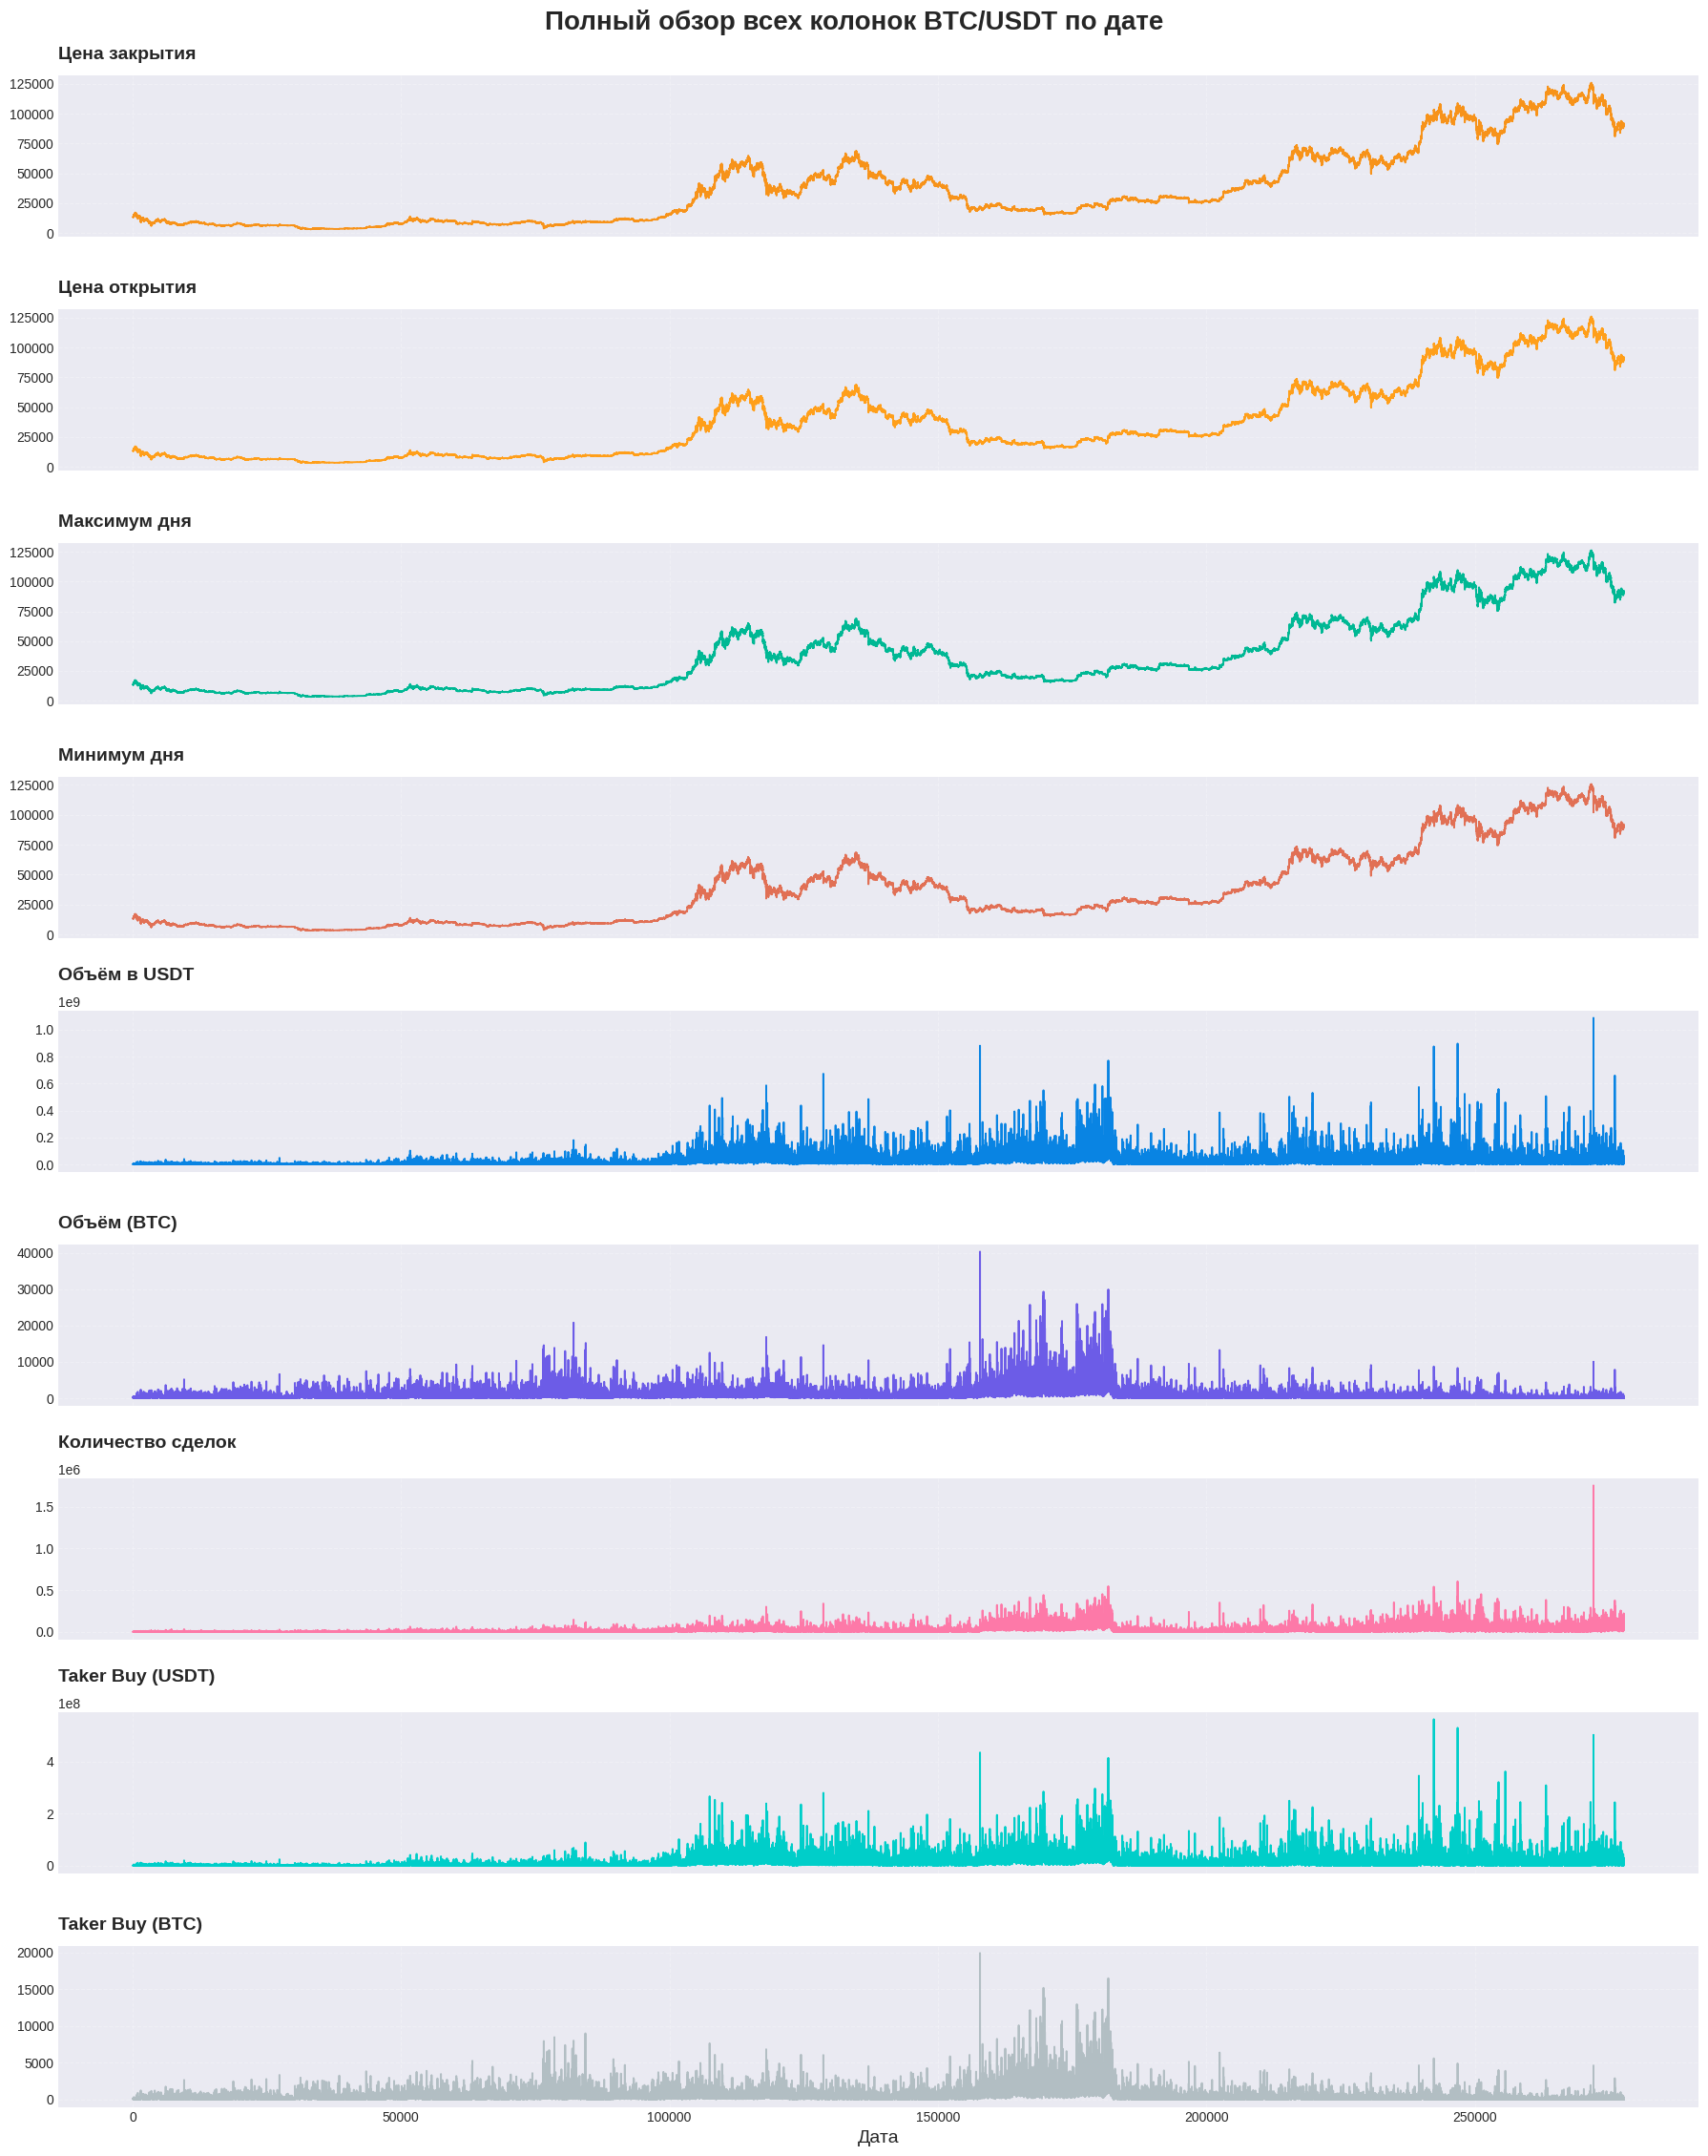

In [ ]:
rename_dict = {
    'Open': 'Цена открытия',
    'High': 'Максимум дня',
    'Low': 'Минимум дня',
    'Close': 'Цена закрытия',
    'Volume': 'Объём (BTC)',
    'Quote asset volume': 'Объём в USDT',
    'Number of trades': 'Количество сделок',
    'Taker buy base asset volume': 'Taker Buy (BTC)',
    'Taker buy quote asset volume': 'Taker Buy (USDT)',
}

df_plot = df.rename(columns=rename_dict)
df_plot = df_plot.set_index('Date')

cols_to_plot = [
    'Цена закрытия',
    'Цена открытия',
    'Максимум дня',
    'Минимум дня',
    'Объём в USDT',
    'Объём (BTC)',
    'Количество сделок',
    'Taker Buy (USDT)',
    'Taker Buy (BTC)'
]

colors = [
    '#f7931a',
    '#ff9f1a',
    '#00b894',
    '#e17055',
    '#0984e3',
    '#6c5ce7',
    '#fd79a8',
    '#00cec9',
    '#b2bec3'
]

fig, ax = plt.subplots(len(cols_to_plot), 1, figsize=(18, 23), sharex=True)

for i, col in enumerate(cols_to_plot):
    ax[i].plot(df_plot.index, df_plot[col], color=colors[i], linewidth=1.4)
    ax[i].set_title(col, fontsize=14, fontweight='bold', loc='left', pad=12)
    ax[i].set_ylabel('')
    ax[i].grid(alpha=0.25, linestyle='--')

    if 'Цена' in col or 'Максимум' in col or 'Минимум' in col:
        ax[i].ticklabel_format(style='plain', axis='y')

ax[-1].set_xlabel('Дата', fontsize=14)

plt.suptitle('Полный обзор всех колонок BTC/USDT по дате',
             fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.45)
plt.show()

In [ ]:
plt.figure(figsize=(18,6))

plt.plot(df_plot.index, df_plot['Цена закрытия'], label='Close', linewidth=2)
plt.plot(df_plot.index, df_plot['Цена открытия'], label='Open', alpha=0.8)
plt.fill_between(
    df_plot.index,
    df_plot['Минимум дня'],
    df_plot['Максимум дня'],
    color='gray',
    alpha=0.2,
    label='Daily range'
)

plt.title('Динамика цены BTC/USDT и дневной диапазон')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
df_plot['Taker Buy Ratio'] = (
    df_plot['Taker Buy (USDT)'] / df_plot['Объём в USDT']
)

plt.figure(figsize=(18,5))
plt.plot(df_plot.index, df_plot['Taker Buy Ratio'], color='#e17055')
plt.axhline(0.5, linestyle='--', alpha=0.5)

plt.title('Доля агрессивных покупок')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
fig, ax1 = plt.subplots(figsize=(18,5))

ax1.plot(df_plot.index, df_plot['Цена закрытия'], label='Close', linewidth=2)
ax1.set_ylabel('Цена')

ax2 = ax1.twinx()
ax2.plot(
    df_plot.index,
    df_plot['Taker Buy Ratio'],
    color='orange',
    alpha=0.6,
    label='Taker Buy Ratio'
)

ax1.set_title('Цена и давление покупателей')
ax1.grid(alpha=0.3)

plt.show()


In [ ]:
df_plot['Trades per Volume'] = (
    df_plot['Количество сделок'] / df_plot['Объём в USDT']
)

plt.figure(figsize=(18,5))
plt.plot(df_plot.index, df_plot['Trades per Volume'])
plt.title('Интенсивность торгов')
plt.grid(alpha=0.3)
plt.show()


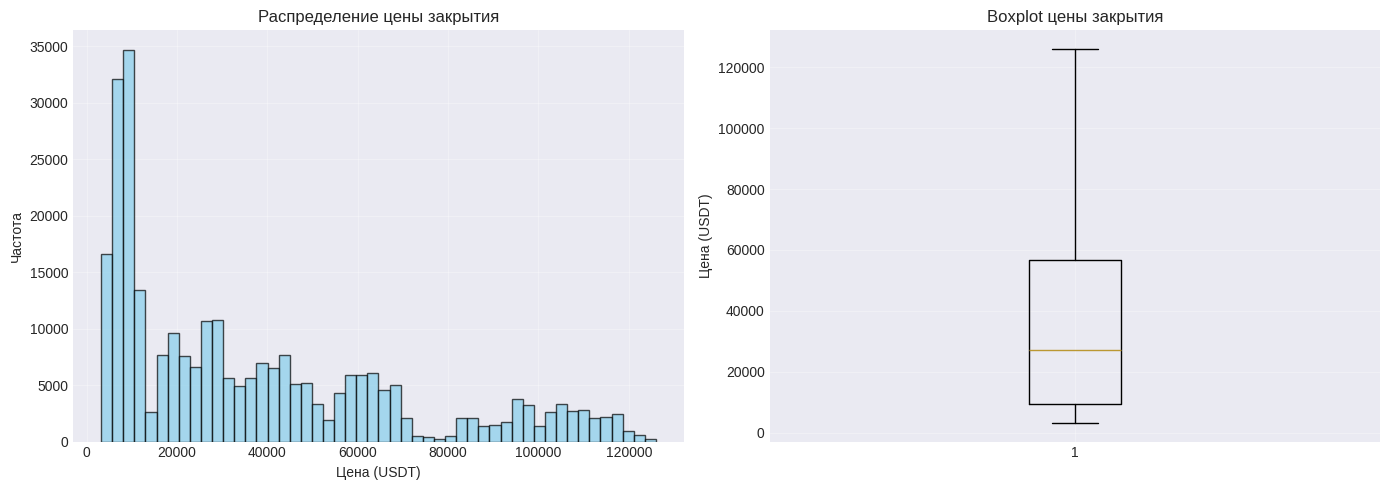

In [18]:
# Гистограмма распределения цен
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Close'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение цены закрытия')
axes[0].set_xlabel('Цена (USDT)')
axes[0].set_ylabel('Частота')
axes[0].grid(True, alpha=0.3)

# Boxplot для выбросов
axes[1].boxplot(df['Close'], vert=True)
axes[1].set_title('Boxplot цены закрытия')
axes[1].set_ylabel('Цена (USDT)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

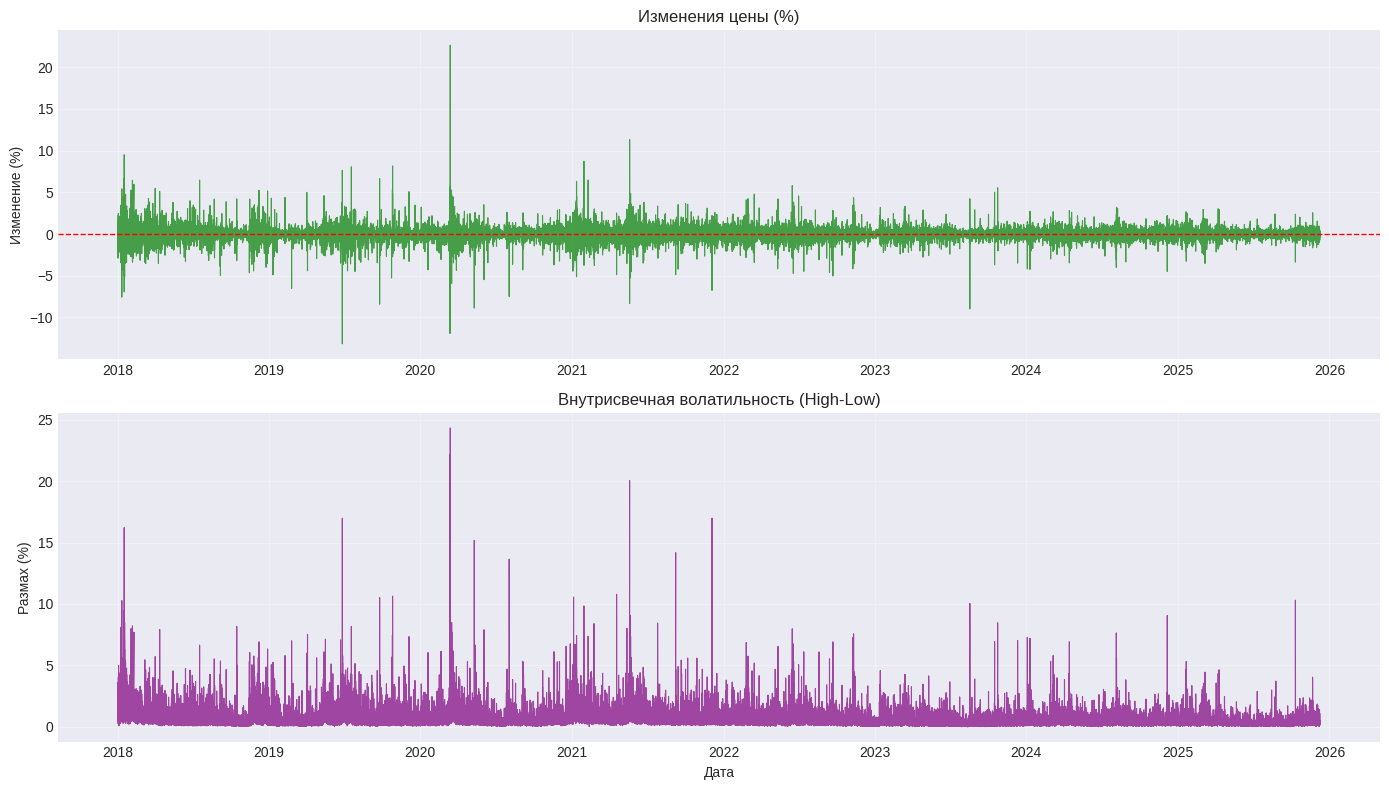

Средняя доходность: 0.00%
Стандартное отклонение доходности: 0.38%
Максимальный рост: 22.63%
Максимальное падение: -13.17%


In [19]:
data = df.copy()

# Считаем дневное изменение цены в процентах
data['Return%'] = data['Close'].pct_change() * 100

# Считаем внутридневную волатильность
data['Range%'] = ((data['High'] - data['Low']) / data['Low']) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# График дневных изменений
axes[0].plot(data['Open time'], data['Return%'], linewidth=0.8, color='green', alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Изменения цены (%)')
axes[0].set_ylabel('Изменение (%)')
axes[0].grid(True, alpha=0.3)

# График внутридневной волатильности
axes[1].plot(data['Open time'], data['Range%'], linewidth=0.8, color='purple', alpha=0.7)
axes[1].set_title('Внутрисвечная волатильность (High-Low)')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Размах (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Средняя доходность: {data['Return%'].mean():.2f}%")
print(f"Стандартное отклонение доходности: {data['Return%'].std():.2f}%")
print(f"Максимальный рост: {data['Return%'].max():.2f}%")
print(f"Максимальное падение: {data['Return%'].min():.2f}%")

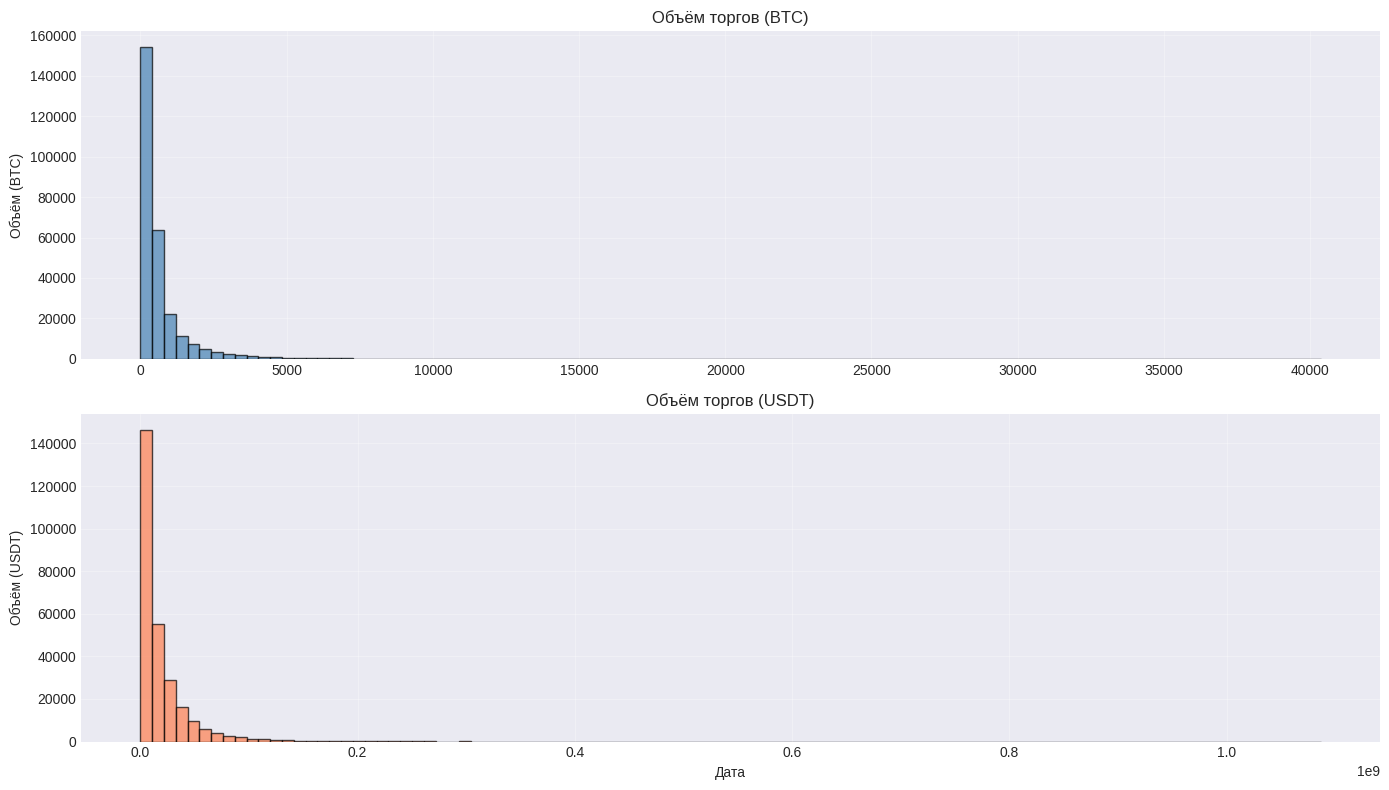

In [20]:
# Посмотрим на объёмы
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
bins = 100

# Объём в BTC
axes[0].hist(df['Volume'], bins=bins, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Объём торгов (BTC)')
axes[0].set_ylabel('Объём (BTC)')
axes[0].grid(True, alpha=0.3)

# Объём в USDT
axes[1].hist(df['Quote asset volume'], bins=bins, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Объём торгов (USDT)')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Объём (USDT)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

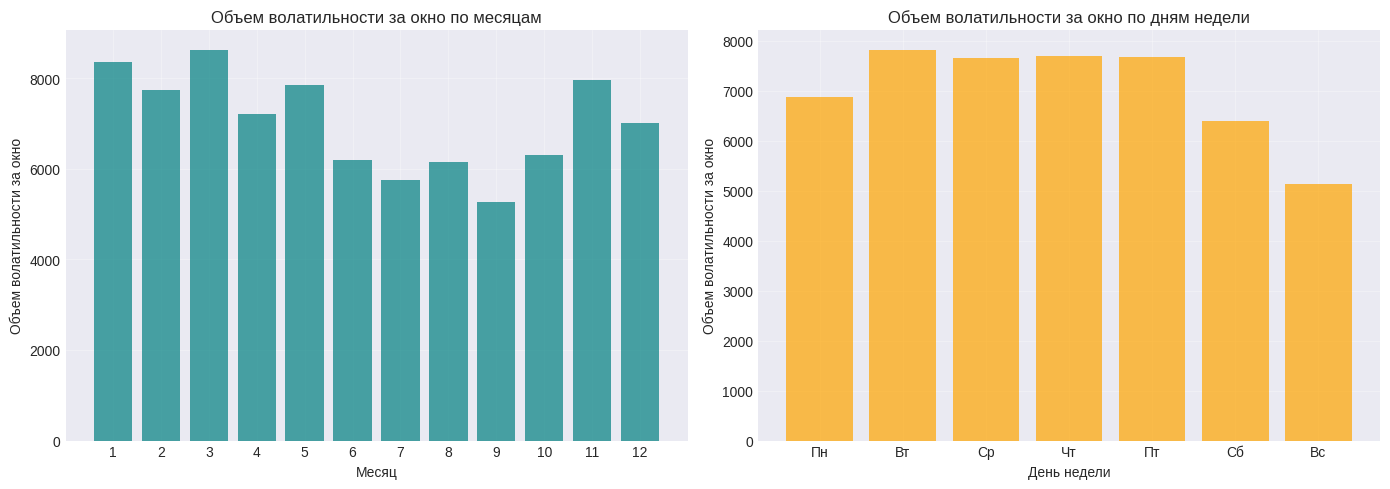

In [21]:
# Объем волатильности за окно
monthly_vol = df.groupby('Month')['Window_Volatility'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_vol.index, monthly_vol.values, color='teal', alpha=0.7)
axes[0].set_title('Объем волатильности за окно по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Объем волатильности за окно')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Объем волатильности за окно по дням недели
dow_vol = df.groupby('DayOfWeek')['Window_Volatility'].mean()
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

axes[1].bar(range(7), dow_vol.values, color='orange', alpha=0.7)
axes[1].set_title('Объем волатильности за окно по дням недели')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Объем волатильности за окно')

axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

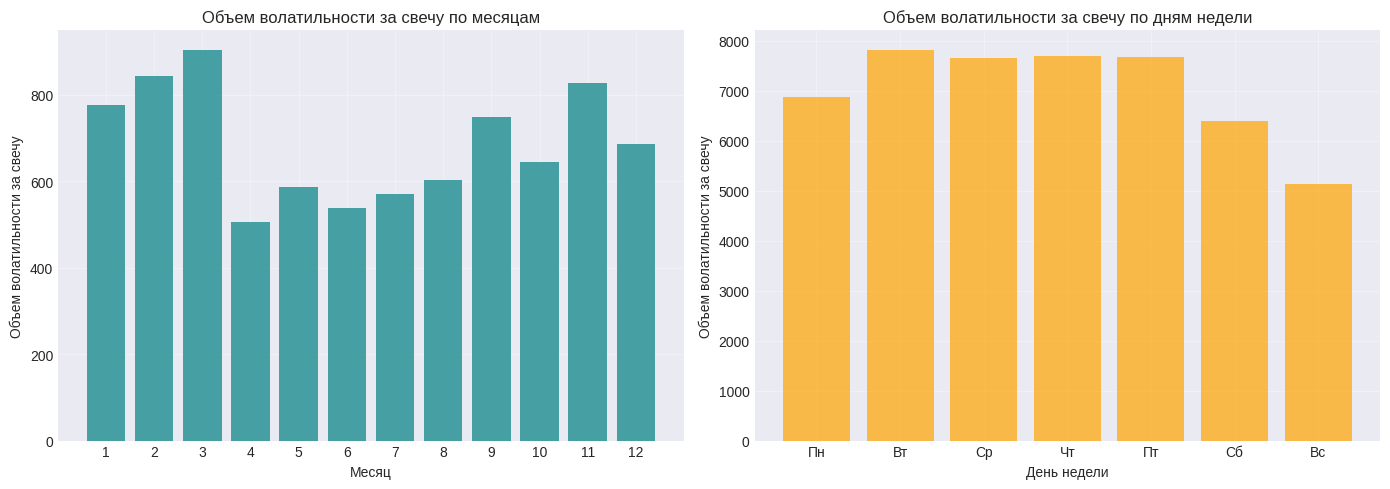

In [22]:
# Объем волатильности за свечу по месяцам
monthly_vol = df.groupby('Month')['Volume'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_vol.index, monthly_vol.values, color='teal', alpha=0.7)
axes[0].set_title('Объем волатильности за свечу по месяцам')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Объем волатильности за свечу')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Объем волатильности за свечу по дням недели
dow_vol = df.groupby('DayOfWeek')['Window_Volatility'].mean()
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

axes[1].bar(range(7), dow_vol.values, color='orange', alpha=0.7)
axes[1].set_title('Объем волатильности за свечу по дням недели')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Объем волатильности за свечу')

axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Статистика по годам:
             mean        min           max          std
Year                                                   
2018   383.422666   4.635181   6626.368185   354.349906
2019   438.965397   0.000000   9305.628362   508.685503
2020   734.135967  35.066062  20821.081669   810.442763
2021   729.729006   0.000000  16858.547327   704.770922
2022  1525.433649  37.462160  40371.405060  1769.268032
2023  1044.821941   0.000000  29961.474690  1765.321613
2024   368.030287  10.238760   9136.883710   435.944629
2025   224.933754   3.985380  10067.891340   301.397972


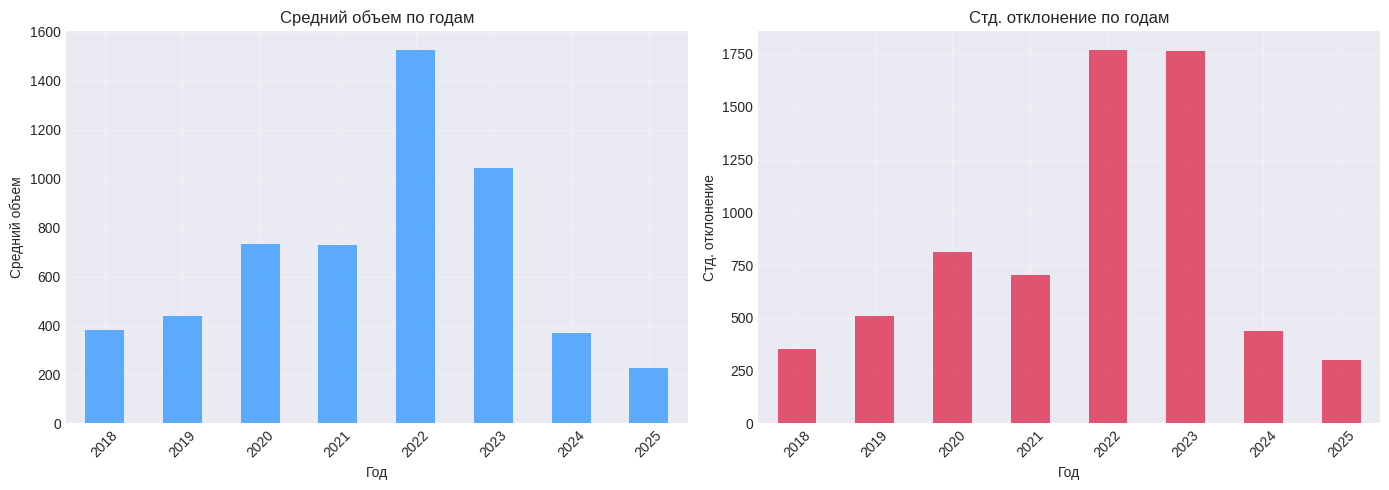

In [23]:
# Средний объем по годам
yearly_stats = df.groupby('Year')['Volume'].agg(['mean', 'min', 'max', 'std'])
print("Статистика по годам:")
print(yearly_stats)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_stats['mean'].plot(kind='bar', ax=axes[0], color='dodgerblue', alpha=0.7)
axes[0].set_title('Средний объем по годам')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Средний объем')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

yearly_stats['std'].plot(kind='bar', ax=axes[1], color='crimson', alpha=0.7)
axes[1].set_title('Стд. отклонение по годам')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Стд. отклонение')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Baseline

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Target']).copy()
y = df['Target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

median_target = y_train.median()
print(f"Медиана Target (Train Set): {median_target:.4f}")

median_predictions = np.ones_like(y_test) * median_target

baseline_mae = mean_absolute_error(y_test, median_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_test, median_predictions))

print("—" * 60)
print("🎯 НАИВНЫЙ БЕЙЗЛАЙН")
print(f"Median MAE:  {baseline_mae:.4f}")

Train: 222139, Test: 55535
Медиана Target (Train Set): 0.9821
————————————————————————————————————————————————————————————
🎯 НАИВНЫЙ БЕЙЗЛАЙН
Median MAE:  0.3279


---
## Этап 2. Аномалии и генерация признаков

### 2.1 Поиск аномалий

In [25]:
from scipy import stats

# Z-score
z_scores = np.abs(stats.zscore(df['Volume']))
volume_outliers_z = z_scores > 3

# IQR
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
volume_outliers_iqr = (df['Volume'] < Q1 - 1.5*IQR) | (df['Volume'] > Q3 + 1.5*IQR)

print(f"Аномалий по Z-score: {volume_outliers_z.sum()}")
print(f"Аномалий по IQR: {volume_outliers_iqr.sum()}")

Аномалий по Z-score: 5376
Аномалий по IQR: 29646


In [26]:
# Тест Граббса
from scipy.stats import t as t_dist
n = len(df['Volume'])
mean_vol = df['Volume'].mean()
std_vol = df['Volume'].std()
G_vals = np.abs((df['Volume'] - mean_vol) / std_vol)
G_max = G_vals.max()
t_crit = t_dist.ppf(1 - 0.05 / (2 * n), n - 2)
G_crit = ((n - 1) / np.sqrt(n)) * np.sqrt(t_crit**2 / (n - 2 + t_crit**2))
volume_outliers_grubbs = G_vals > G_crit

print(f"Аномалий по Граббсу: {volume_outliers_grubbs.sum()}")

Аномалий по Граббсу: 1697


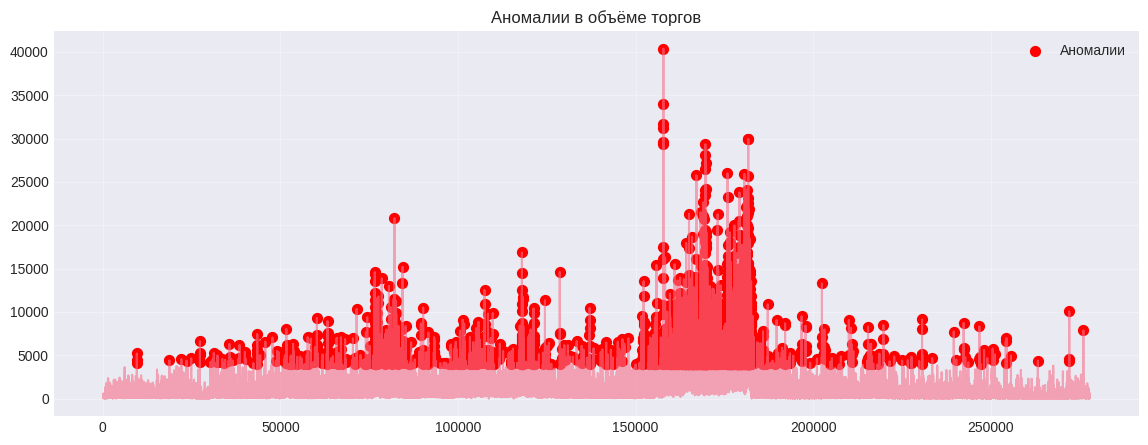

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Volume'], alpha=0.6)
ax.scatter(df.index[volume_outliers_z], df['Volume'][volume_outliers_z], color='red', s=50, label='Аномалии')
ax.set_title('Аномалии в объёме торгов')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [28]:
print("Почему это аномалии:")
print("- Резкие скачки объёма связаны с важными новостями")
print("- Периоды высокой волатильности привлекают трейдеров")
print("- Аномалии несут информацию о рыночном стрессе")
print("\nРешение: оставляем аномалии, создаём признаки")

Почему это аномалии:
- Резкие скачки объёма связаны с важными новостями
- Периоды высокой волатильности привлекают трейдеров
- Аномалии несут информацию о рыночном стрессе

Решение: оставляем аномалии, создаём признаки


In [29]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

X_anomaly = df[['Volume', 'Number of trades', 'High', 'Low']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomaly)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_scaled)

df['is_anomaly'] = (anomaly_labels == -1).astype(int)
print(f"Найдено аномалий: {df['is_anomaly'].sum()}")

Найдено аномалий: 13884


In [30]:
# Оценка качества
extreme_target = (df['Target'] < df['Target'].quantile(0.05)) |  (df['Target'] > df['Target'].quantile(0.95))

from sklearn.metrics import precision_score, recall_score, f1_score
prec = precision_score(extreme_target, df['is_anomaly'], zero_division=0)
rec = recall_score(extreme_target, df['is_anomaly'], zero_division=0)
f1 = f1_score(extreme_target, df['is_anomaly'], zero_division=0)
print(f"Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

Precision: 0.114, Recall: 0.057, F1: 0.076


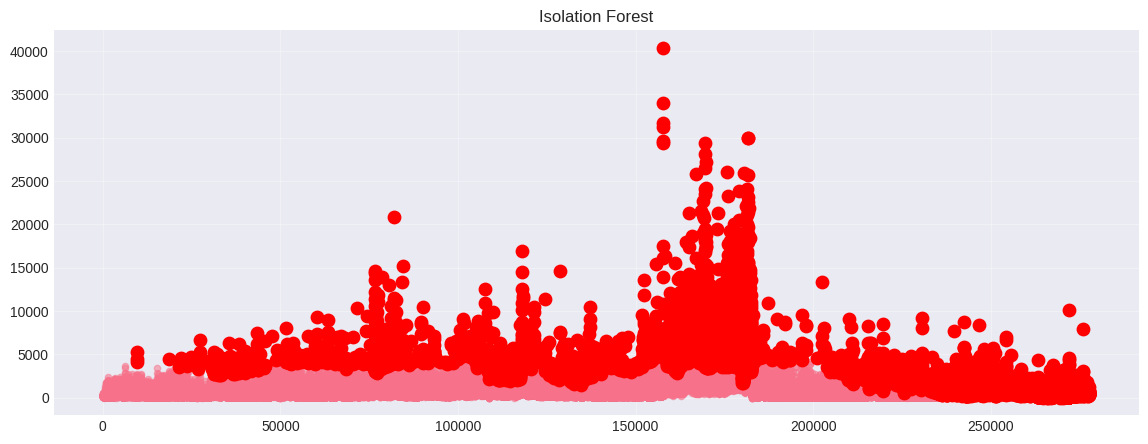

In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
normal = df['is_anomaly'] == 0
anomaly = df['is_anomaly'] == 1
ax.scatter(df.index[normal], df['Volume'][normal], alpha=0.5, s=20)
ax.scatter(df.index[anomaly], df['Volume'][anomaly], color='red', s=80)
ax.set_title('Isolation Forest')
ax.grid(True, alpha=0.3)
plt.show()

### 2.2 Генерация фич

In [32]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 277674 entries, 96 to 277771
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Open time                     277674 non-null  datetime64[ns]
 1   Open                          277674 non-null  float64       
 2   High                          277674 non-null  float64       
 3   Low                           277674 non-null  float64       
 4   Close                         277674 non-null  float64       
 5   Volume                        277674 non-null  float64       
 6   Close time                    277674 non-null  datetime64[ns]
 7   Quote asset volume            277674 non-null  float64       
 8   Number of trades              277674 non-null  int64         
 9   Taker buy base asset volume   277674 non-null  float64       
 10  Taker buy quote asset volume  277674 non-null  float64       
 11  Year             

In [33]:
candle_stat_features = [
    "Open", "Low", "High", "Close", "Volume", "Quote asset volume", "Number of trades",
    "Taker buy base asset volume", "Taker buy quote asset volume",   
]
time_features = [
    'IsWeekend', 'Year', 'Month', 'DayOfWeek', 'Quarter',
]
datetime_features = [
    'Open time', 'Close time', 'Date', 
]
window_features = [
    'Window_Volatility'
]
other_features = ['is_anomaly']
target_column = 'Target'
target_features = ['Target']
all_features = candle_stat_features + time_features + window_features + other_features

assert set(all_features + target_features).issubset(set(df.columns)), "Некоторые признаки отсутствуют в данных!"

cat_features = [
    'IsWeekend', 'Year', 'Month', 'DayOfWeek', 'Quarter',
]

#### Target Encoding

In [34]:
import category_encoders as ce

X_enc = df[['DayOfWeek']]
y_enc = df['Target']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = ce.TargetEncoder(cols=['DayOfWeek'], smoothing=10.0, handle_unknown='value', handle_missing='value')

encoder.fit(X_train, y_train)

X_train_encoded = encoder.transform(X_train)
X_test_encoded = encoder.transform(X_test)

df['day_of_week_te'] = pd.Series(dtype=float)
df.loc[X_train.index, 'day_of_week_te'] = X_train_encoded['DayOfWeek'].values
df.loc[X_test.index, 'day_of_week_te'] = X_test_encoded['DayOfWeek'].values

other_features.append('day_of_week_te')
print("Target Encoding применён")

Target Encoding применён


#### Временные признаки

In [35]:
# Синус/косинус для дня недели и месяца
df['day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

time_features.extend(['day_sin', 'day_cos', 'month_sin', 'month_cos'])

print("Временные признаки созданы")

Временные признаки созданы


#### Контекстные признаки

Признаки свечей

In [36]:
# Ranges
df["Abs_Range"] = (df['High'] - df['Low']).abs()
df["Relative_Range"] = (df['High'] - df['Low']) / (df['Open'] + 1e-6)

# Log returns
df['Log_Return'] = np.log(df['Close'] / df['Open'] + 1e-6)
df["Log_Return_Abs"] = df['Log_Return'].abs()

# Trades
df['Avg_Volume_per_Trade'] = df['Volume'] / (df['Number of trades'] + 1e-6)
df['Taker_Buy_Ratio'] = df['Taker buy quote asset volume'] / (df['Quote asset volume'] + 1e-6)

candle_stat_features.extend([
    "Abs_Range", "Relative_Range", "Log_Return", "Log_Return_Abs",
    "Avg_Volume_per_Trade", "Taker_Buy_Ratio"
])
print("Признаки свечей созданы")

Признаки свечей созданы


Оконные признаки

In [37]:
window_sizes = [
    window_size_target // 4,
    window_size_target // 2,
    window_size_target,
    window_size_target * 2,
    window_size_target * 4,
]
window_sizes.sort()

cols_arr_1 = [
    'Volume',
    'Quote asset volume',
    'Number of trades',
    'Abs_Range',
    'Log_Return',
    'Log_Return_Abs',
    'Avg_Volume_per_Trade',
    'Taker_Buy_Ratio',
]

added_features = []
eps = 1e-6

for col in tqdm(cols_arr_1):
    for w in window_sizes:
        # Скользящие статистики
        df[f'{col}_ma_{w}'] = df[col].rolling(window=w).mean()
        df[f'{col}_std_{w}'] = df[col].rolling(window=w).std()
        df[f'{col}_min_{w}'] = df[col].rolling(window=w).min()
        df[f'{col}_max_{w}'] = df[col].rolling(window=w).max()
        df[f'{col}_median_{w}'] = df[col].rolling(window=w).median()
        
        # Отношения к лагам прошлых окон
        df[f'{col}_ma_rel_to_lag_{w}'] = df[f'{col}_ma_{w}'] / (df[f'{col}_ma_{w}'].shift(w) + eps)
        df[f'{col}_std_rel_to_lag_{w}'] = df[f'{col}_std_{w}'] / (df[f'{col}_std_{w}'].shift(w) + eps)
        df[f'{col}_median_rel_to_lag_{w}'] = df[f'{col}_median_{w}'] / (df[f'{col}_median_{w}'].shift(w) + eps)
        
        added_features.extend([
            f'{col}_ma_rel_to_lag_{w}',
            f'{col}_std_rel_to_lag_{w}',
            f'{col}_median_rel_to_lag_{w}',
        ])
    
    for short_w, long_w in zip(window_sizes[:-1], window_sizes[1:]):
        # Отношения между быстрыми/медленными скользящими
        df[f'{col}_ma_ratio_{short_w}to{long_w}'] = \
            df[f'{col}_ma_{short_w}'] / (df[f'{col}_ma_{long_w}'] + eps)
        df[f'{col}_std_ratio_{short_w}to{long_w}'] = \
            df[f'{col}_std_{short_w}'] / (df[f'{col}_std_{long_w}'] + eps)
        df[f'{col}_min_ratio_{short_w}to{long_w}'] = \
            df[f'{col}_min_{short_w}'] / (df[f'{col}_min_{long_w}'] + eps)
        df[f'{col}_max_ratio_{short_w}to{long_w}'] = \
            df[f'{col}_max_{short_w}'] / (df[f'{col}_max_{long_w}'] + eps)
        df[f'{col}_median_ratio_{short_w}to{long_w}'] = \
            df[f'{col}_median_{short_w}'] / (df[f'{col}_median_{long_w}'] + eps)
            
        added_features.extend([
            f'{col}_ma_ratio_{short_w}to{long_w}',
            f'{col}_std_ratio_{short_w}to{long_w}',
            f'{col}_min_ratio_{short_w}to{long_w}',
            f'{col}_max_ratio_{short_w}to{long_w}',
            f'{col}_median_ratio_{short_w}to{long_w}',
        ])
    
    for w in window_sizes:
        # Абсолютные значения нам бесполезны
        df.drop(columns=[
            f'{col}_ma_{w}',
            f'{col}_std_{w}',
            f'{col}_min_{w}',
            f'{col}_max_{w}',
            f'{col}_median_{w}',
        ], inplace=True)

print(f"Добавлено новых признаков: {len(added_features)}")
print(f"Новые признаки:")
print(added_features)

window_features += added_features
print("Оконные признаки созданы")

100%|██████████| 8/8 [00:13<00:00,  1.68s/it]

Добавлено новых признаков: 280
Новые признаки:
['Volume_ma_rel_to_lag_24', 'Volume_std_rel_to_lag_24', 'Volume_median_rel_to_lag_24', 'Volume_ma_rel_to_lag_48', 'Volume_std_rel_to_lag_48', 'Volume_median_rel_to_lag_48', 'Volume_ma_rel_to_lag_96', 'Volume_std_rel_to_lag_96', 'Volume_median_rel_to_lag_96', 'Volume_ma_rel_to_lag_192', 'Volume_std_rel_to_lag_192', 'Volume_median_rel_to_lag_192', 'Volume_ma_rel_to_lag_384', 'Volume_std_rel_to_lag_384', 'Volume_median_rel_to_lag_384', 'Volume_ma_ratio_24to48', 'Volume_std_ratio_24to48', 'Volume_min_ratio_24to48', 'Volume_max_ratio_24to48', 'Volume_median_ratio_24to48', 'Volume_ma_ratio_48to96', 'Volume_std_ratio_48to96', 'Volume_min_ratio_48to96', 'Volume_max_ratio_48to96', 'Volume_median_ratio_48to96', 'Volume_ma_ratio_96to192', 'Volume_std_ratio_96to192', 'Volume_min_ratio_96to192', 'Volume_max_ratio_96to192', 'Volume_median_ratio_96to192', 'Volume_ma_ratio_192to384', 'Volume_std_ratio_192to384', 'Volume_min_ratio_192to384', 'Volume_max_ra

In [38]:
# В процессе генерации оконных признаков появились пропуски
df.dropna(inplace=True)

In [39]:
all_features = candle_stat_features + time_features + window_features + other_features + target_features + datetime_features
assert len(all_features) == len(set(all_features)), "Есть дублирующиеся признаки!"
assert len(all_features) == len(df.columns), "Некоторые признаки отсутствуют!"

### 2.3 Модели

In [40]:
from lightgbm import LGBMRegressor
def get_model(**custom_params):
    default_params = {
        'n_estimators': 1000,
        'learning_rate': 0.01,
        'max_depth': -1,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }
    default_params.update(custom_params)
    print(f"Используемые параметры: {default_params}")
    return LGBMRegressor(**default_params)

#### Отбор признаков

In [41]:
from sklearn.model_selection import train_test_split
from lightgbm import Dataset

# Black/White lists for training
exclude_cols = (
    datetime_features +
    target_features + 
    candle_stat_features + 
    ['Year', "Month", "Quarter"]
)
include_cols = (
    time_features +
    window_features +
    other_features
)

feature_cols = [col for col in df.columns if col not in exclude_cols and col in include_cols]
cat_features_filtered = [col for col in cat_features if col in feature_cols]

X = df[feature_cols]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(f"Признаков: {len(feature_cols)}")

Признаков: 289


In [42]:
# Обучаем базовую модель
model = get_model(verbose=1)
model.fit(
    X_train, y_train,
    categorical_feature=cat_features_filtered,
)

Используемые параметры: {'n_estimators': 1000, 'learning_rate': 0.01, 'max_depth': -1, 'random_state': 42, 'n_jobs': -1, 'verbose': 1}
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.118426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 71694
[LightGBM] [Info] Number of data points in the train set: 221525, number of used features: 289
[LightGBM] [Info] Start training from score 1.066387


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


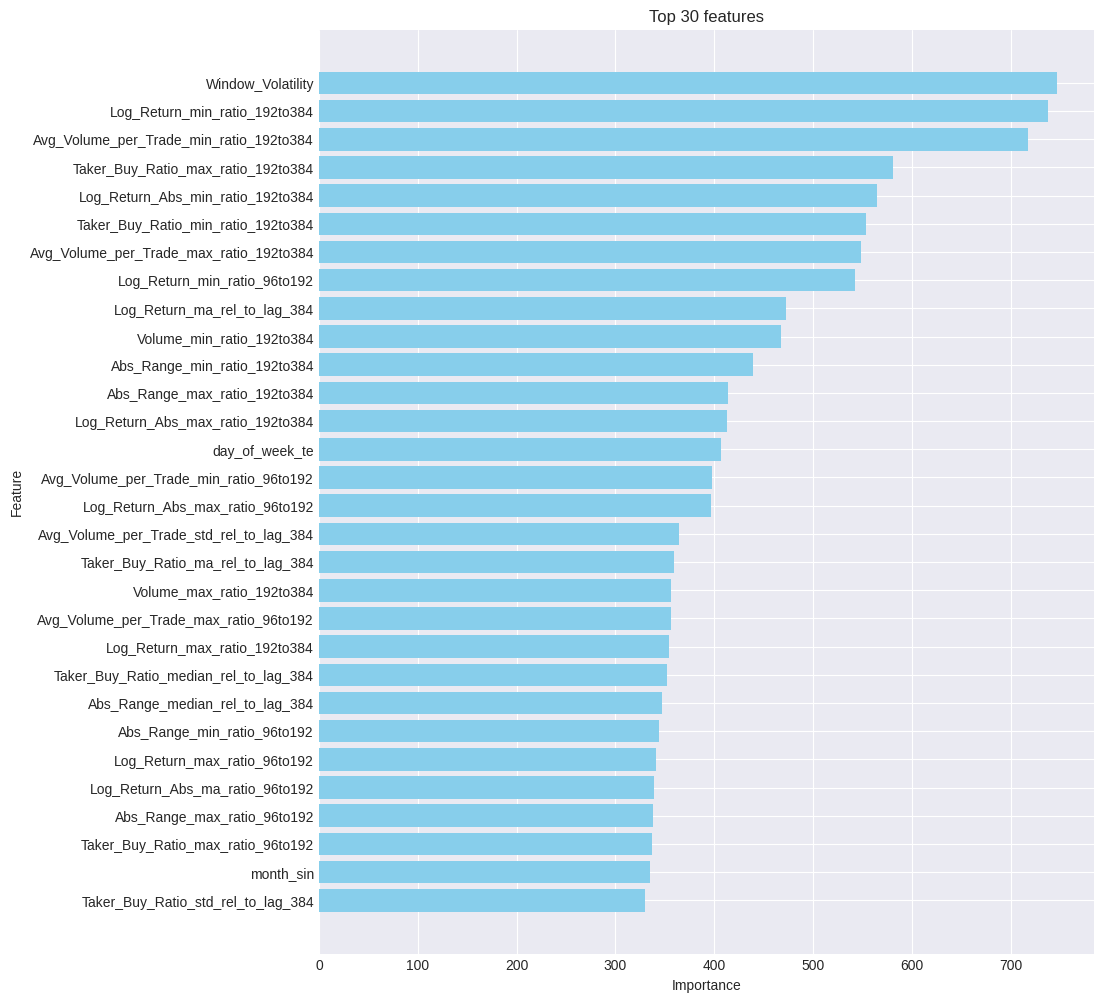

In [43]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_k = 30
plt.figure(figsize=(10, 12))
plt.barh(
    feature_importance_df['Feature'][:top_k][::-1],
    feature_importance_df['Importance'][:top_k][::-1],
    color='skyblue'
)
plt.title(f'Top {top_k} features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [44]:
# Корреляция с таргетом
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Топ-10 по корреляции:\n")
print(correlations.head(10))

Топ-10 по корреляции:

day_of_week_te                          0.292181
Log_Return_Abs_ma_ratio_192to384        0.279362
Abs_Range_ma_ratio_192to384             0.271241
Log_Return_std_ratio_192to384           0.262393
Abs_Range_median_ratio_192to384         0.241532
Log_Return_Abs_std_ratio_192to384       0.238203
Log_Return_Abs_ma_rel_to_lag_192        0.236105
Volume_ma_ratio_192to384                0.235833
Log_Return_Abs_median_ratio_192to384    0.233306
Quote asset volume_ma_ratio_192to384    0.232379
dtype: float64


In [45]:
# Используем только лучшие фичи
top_features = feature_importance_df['Feature'][:top_k].tolist()

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]
cat_features_filtered = [col for col in cat_features if col in top_features]

model_selected = get_model(verbose=1)
model_selected.fit(
    X_train_selected, y_train,
    categorical_feature=[col for col in cat_features_filtered if col in top_features],
)

Используемые параметры: {'n_estimators': 1000, 'learning_rate': 0.01, 'max_depth': -1, 'random_state': 42, 'n_jobs': -1, 'verbose': 1}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002609 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7159
[LightGBM] [Info] Number of data points in the train set: 221525, number of used features: 30
[LightGBM] [Info] Start training from score 1.066387


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Сравнение результатов

In [46]:
from sklearn.ensemble import GradientBoostingRegressor

pred_base = model.predict(X_test)
mae_base = mean_absolute_error(y_test, pred_base)

pred_new = model_selected.predict(X_test_selected)
mae_new = mean_absolute_error(y_test, pred_new)

print("—" * 60)
print(f"Наивный baseline: {baseline_mae:.4f}")
print(f"Базовая модель ({len(feature_cols)} признаков): {mae_base:.4f}")
print(f"С новыми признаками ({len(top_features)} признаков): {mae_new:.4f}")
print("—" * 60)

————————————————————————————————————————————————————————————
Наивный baseline: 0.3279
Базовая модель (289 признаков): 0.2800
С новыми признаками (30 признаков): 0.2842
————————————————————————————————————————————————————————————


## Этап 3. Интерпретация и диагностика моделей

In [47]:
# Для удобства переопределим переменные
model = model_selected

y_train_selected = y_train.copy()
y_test_selected  = y_test.copy()

X_train = X_train_selected.copy()
X_test  = X_test_selected.copy()

y_train = y_train.copy()
y_test  = y_test.copy()

#### SHAP глобальный

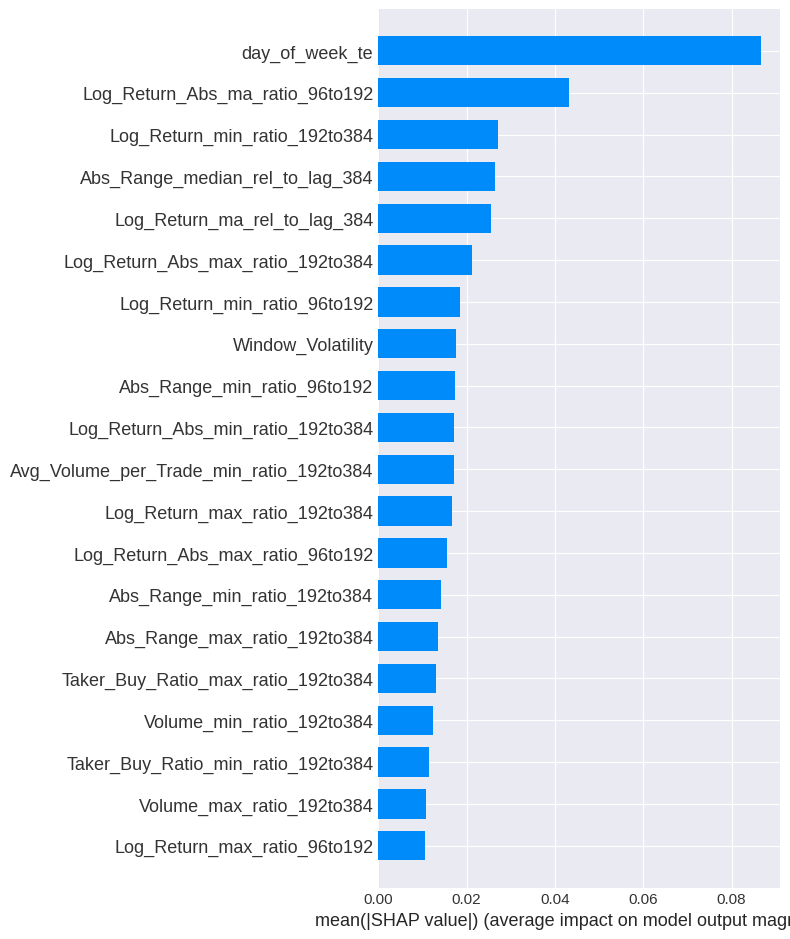

In [48]:
import shap
explainer = shap.TreeExplainer(model)

# Глобальная важность признаков
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_type="bar")

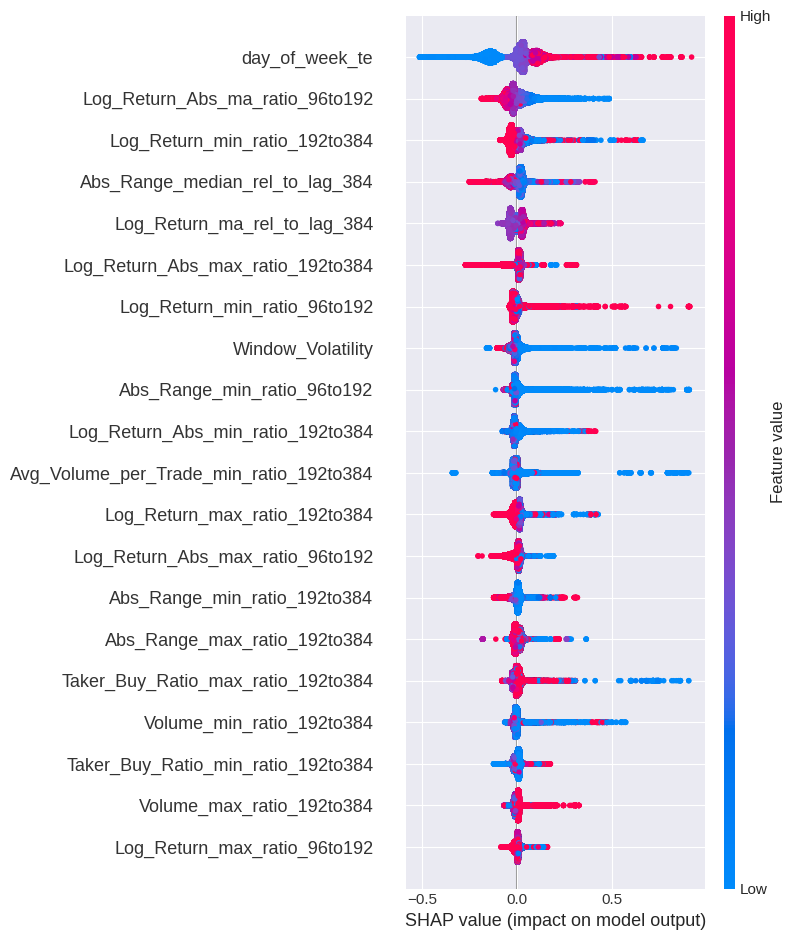

In [49]:
# Глобальное влияние признаков
shap.summary_plot(shap_values, X_train)

#### Shap локальный

------------------------------------------------------------
Локальная интерпретация для записи: 42


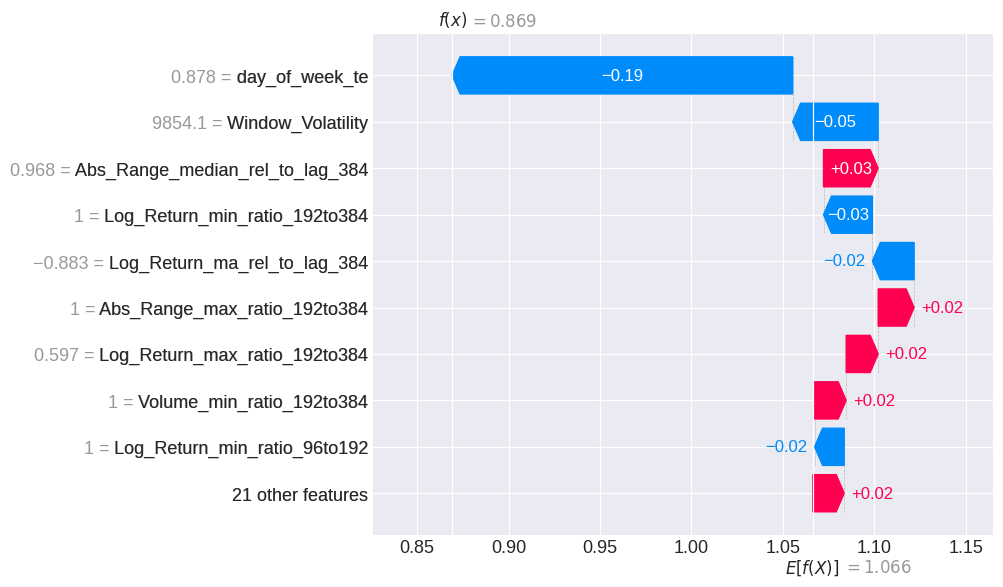

Данные которые объясняем:


,222432
Window_Volatility,9854.100000
Log_Return_min_ratio_192to384,1.000082
Avg_Volume_per_Trade_min_ratio_192to384,1.276284
Taker_Buy_Ratio_max_ratio_192to384,0.999999
Log_Return_Abs_min_ratio_192to384,0.784111
Taker_Buy_Ratio_min_ratio_192to384,0.999996
Avg_Volume_per_Trade_max_ratio_192to384,0.999976
Log_Return_min_ratio_96to192,1.000082
Log_Return_ma_rel_to_lag_384,-0.883498
Volume_min_ratio_192to384,1.000000


------------------------------------------------------------
Локальная интерпретация для записи: 100


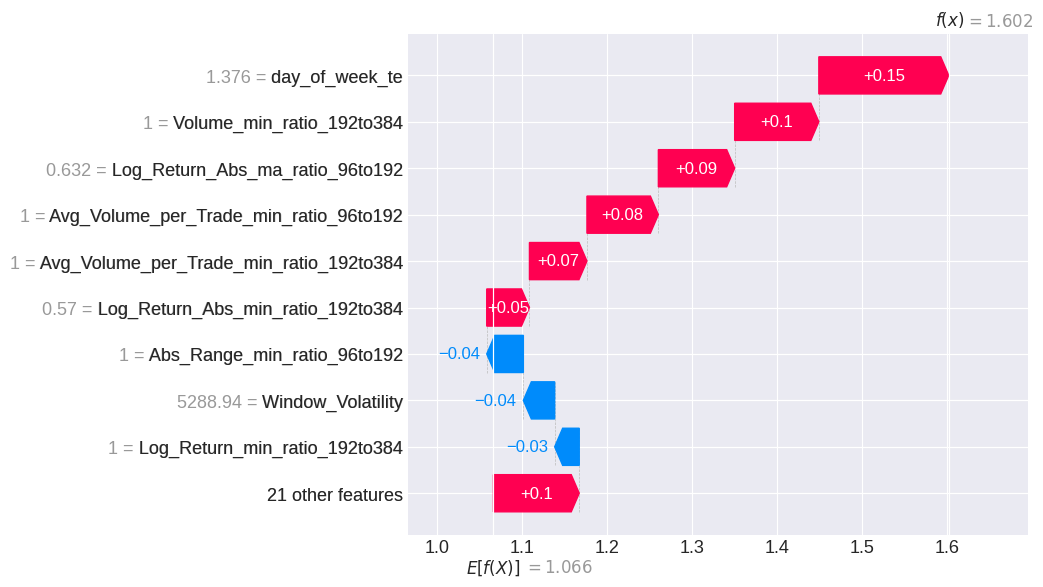

Данные которые объясняем:


,222490
Window_Volatility,5288.940000
Log_Return_min_ratio_192to384,1.000082
Avg_Volume_per_Trade_min_ratio_192to384,0.999864
Taker_Buy_Ratio_max_ratio_192to384,0.999999
Log_Return_Abs_min_ratio_192to384,0.570458
Taker_Buy_Ratio_min_ratio_192to384,0.999996
Avg_Volume_per_Trade_max_ratio_192to384,0.999976
Log_Return_min_ratio_96to192,0.253120
Log_Return_ma_rel_to_lag_384,-26.533488
Volume_min_ratio_192to384,1.000000


------------------------------------------------------------
Локальная интерпретация для записи: 223


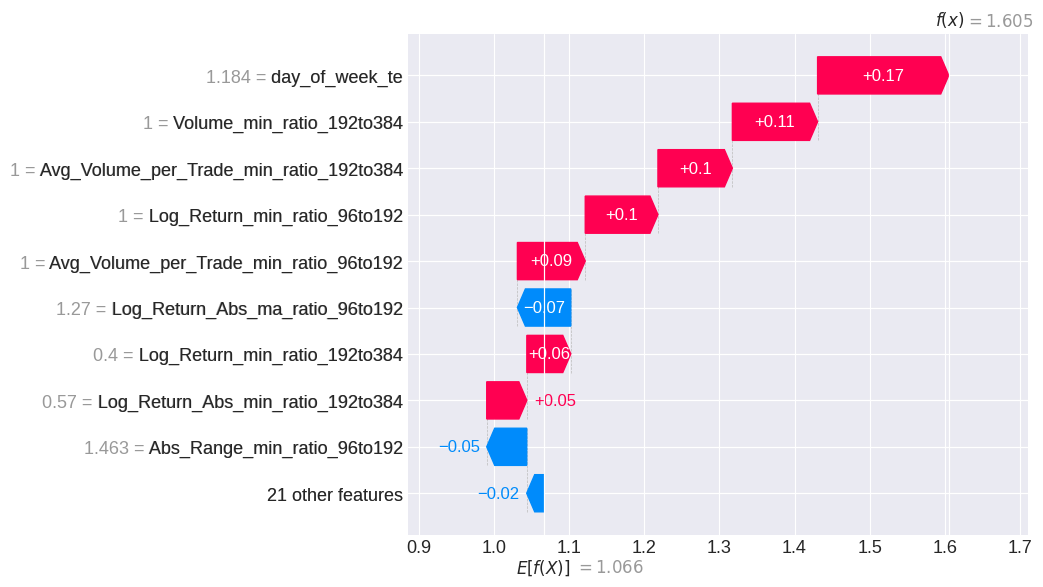

Данные которые объясняем:


,222613
Window_Volatility,8858.940000
Log_Return_min_ratio_192to384,0.399564
Avg_Volume_per_Trade_min_ratio_192to384,0.999859
Taker_Buy_Ratio_max_ratio_192to384,0.999999
Log_Return_Abs_min_ratio_192to384,0.570458
Taker_Buy_Ratio_min_ratio_192to384,0.999996
Avg_Volume_per_Trade_max_ratio_192to384,0.999977
Log_Return_min_ratio_96to192,1.000206
Log_Return_ma_rel_to_lag_384,-0.772276
Volume_min_ratio_192to384,1.000000


In [50]:
# Локальная интерпретация через SHAP waterfall
# индекс объясняемой записи
ids = [42, 100, 223]
for i in ids:
    print("-" * 60)
    print("Локальная интерпретация для записи:", i)
    x = X_test.iloc[i:i+1].copy()

    shap_val_single = explainer.shap_values(x)

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_val_single[0],
            base_values=explainer.expected_value,
            data=x.iloc[0],
            feature_names=x.columns)
    )

    print("Данные которые объясняем:")
    display(x.T)

#### Lime локальный

------------------------------------------------------------
LIME интерпретация для записи: 42


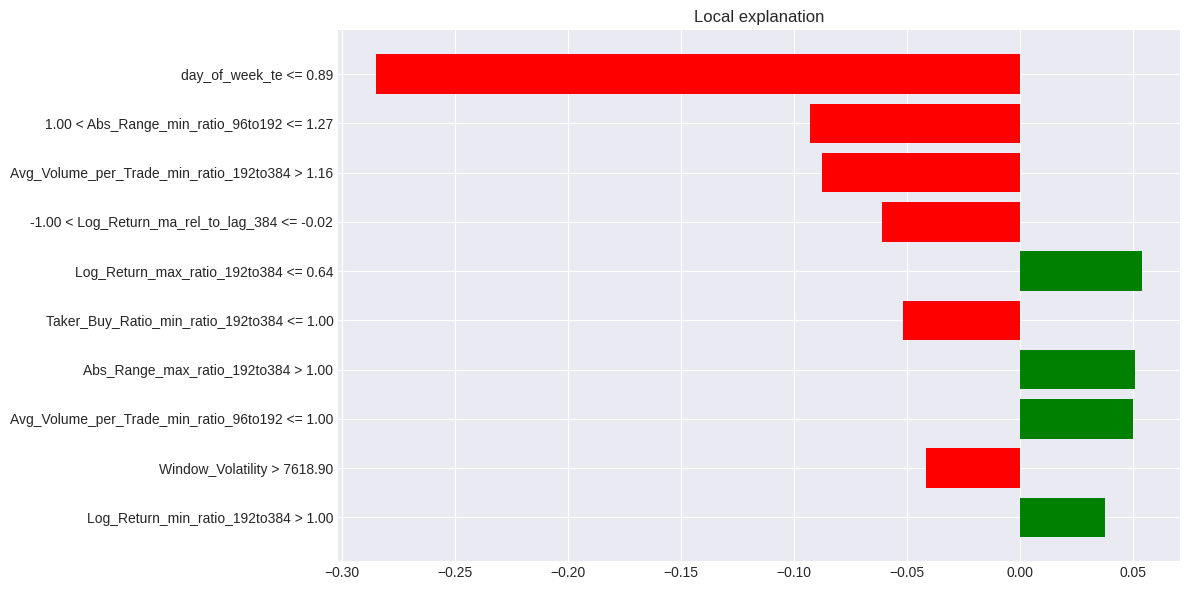

------------------------------------------------------------
LIME интерпретация для записи: 100


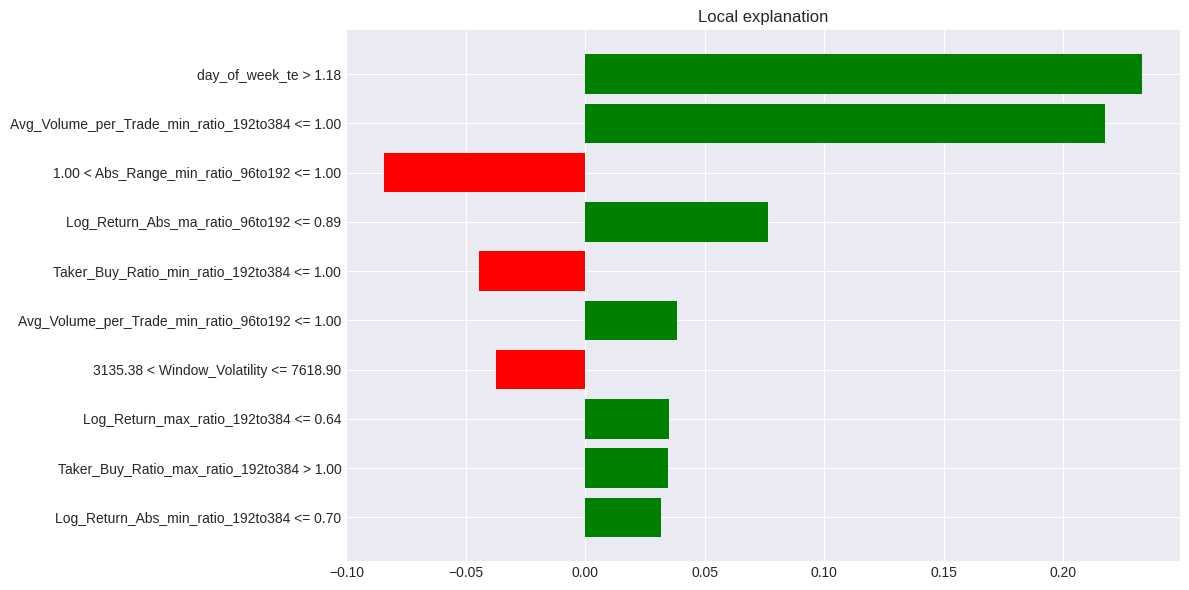

------------------------------------------------------------
LIME интерпретация для записи: 223


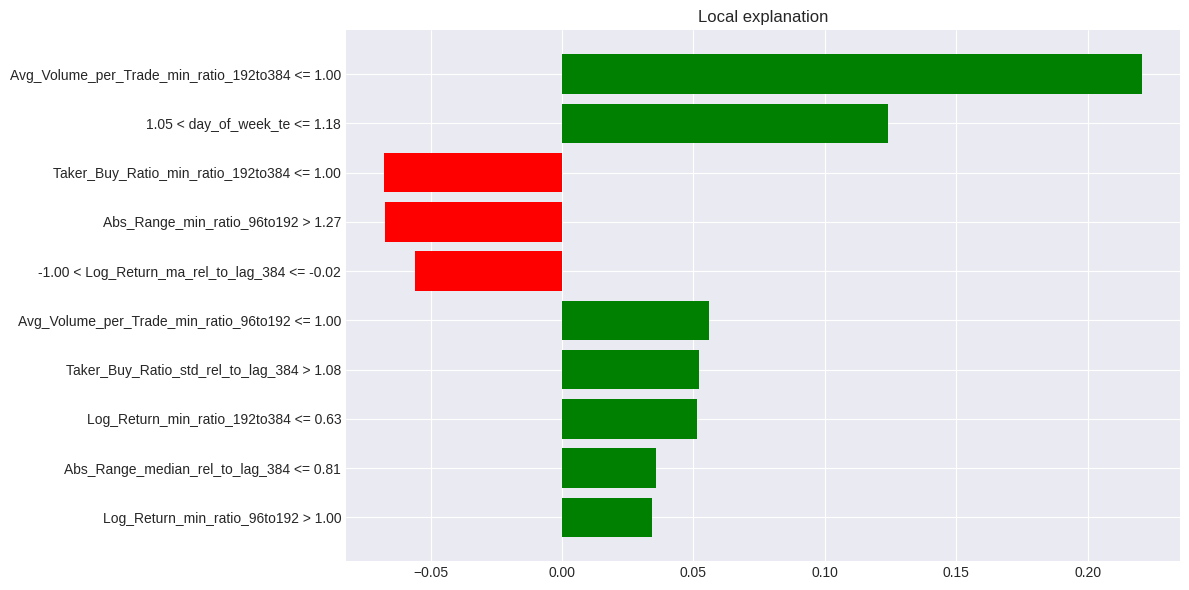

In [53]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    mode='regression'
)

for i in ids:
    print("-" * 60)
    print("LIME интерпретация для записи:", i)
    lime_exp = lime_explainer.explain_instance(
        data_row=X_test.iloc[i],
        predict_fn=model.predict
    )
    # lime_exp.show_in_notebook()
    fig = lime_exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

#### SHAP vs LIME локально

--------------------------------------------------------------------------------
Интерпретация для записи 42:
Предсказание: 0.8691, Истинное значение: 0.5034


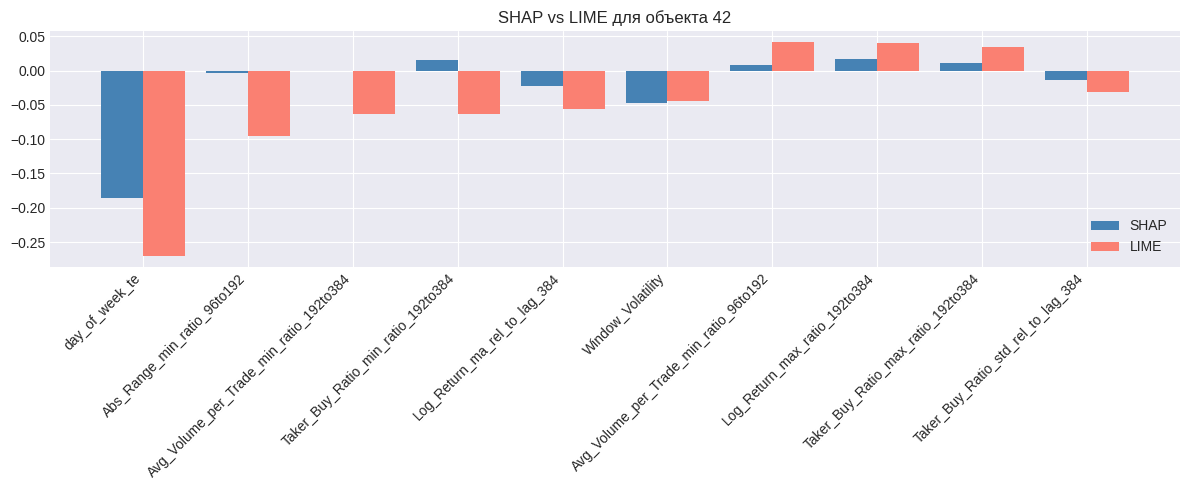

--------------------------------------------------------------------------------
Интерпретация для записи 100:
Предсказание: 1.6016, Истинное значение: 1.1599


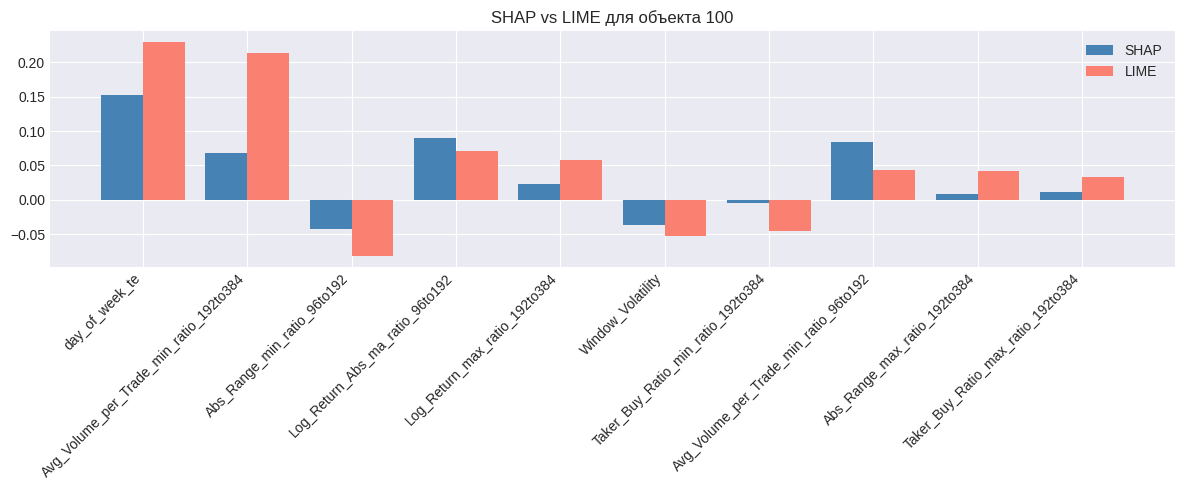

--------------------------------------------------------------------------------
Интерпретация для записи 223:
Предсказание: 1.6053, Истинное значение: 1.0139


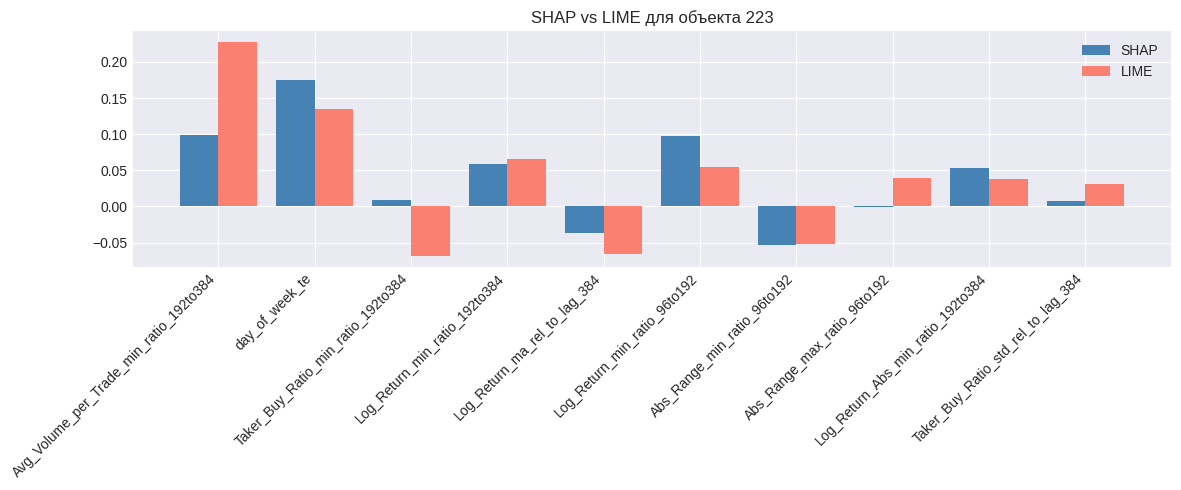

In [54]:
top_k = 10

for i in ids:
    # Предсказание
    pred = model.predict(X_test.iloc[i:i+1])[0]
    true = y_test.iloc[i]
    print("-" * 80)
    print(f"Интерпретация для записи {i}:")
    print(f"Предсказание: {pred:.4f}, Истинное значение: {true:.4f}")

    # Получаем SHAP
    shap_val_single = explainer.shap_values(X_test.iloc[i:i+1].copy())
    importance_shap = pd.Series(shap_val_single[0], index=X_test.columns)

    # Получаем Lime
    lime_exp = lime_explainer.explain_instance(
        data_row=X_test.iloc[i].copy(),
        predict_fn=model.predict
    )
    lime_exp = lime_exp.as_list()
    # Приводим к формату как у SHAP
    cleaner = lambda s : (
        s
        .replace('=', '')
        .replace('<', '!')
        .replace('>', '!')
        .strip()
        .split('!')
    )
    get_name = lambda s : (
        (s[0] if len(s) == 2 else s[1]).strip()
    )
    names = [get_name(cleaner(name)) for name, _ in lime_exp]
    values = np.array([value for _, value in lime_exp])

    importance_lime = pd.Series(values, index=names)

    # Сортируем
    importance_lime = importance_lime.sort_values(ascending=False, key=abs)
    importance_shap = importance_shap.sort_values(ascending=False, key=abs)

    # Синхронизируем
    order = importance_lime.index
    importance_lime = importance_lime.reindex(order)
    importance_shap = importance_shap.reindex(order)

    # Оставляем только топ-k
    importance_lime = importance_lime.head(top_k)
    importance_shap = importance_shap.head(top_k)

    # Визуализация
    plt.figure(figsize=(12, 5))
    x = np.arange(len(importance_shap))
    width = 0.4
    plt.bar(x - width/2, importance_shap.values, label='SHAP', color='steelblue', width=width)
    plt.bar(x + width/2, importance_lime.values, label='LIME', color='salmon', width=width)
    plt.legend()
    plt.xticks(x, order, rotation=45, ha='right')
    plt.title(f'SHAP vs LIME для объекта {i}')
    plt.tight_layout()
    plt.show()

### Shap embedings

In [55]:
def get_shap_embedings(model, X):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap_values = np.array(shap_values)
    return shap_values

emb = get_shap_embedings(model, X_train)

In [56]:
# Выделяем аномалии в SHAP пространстве
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

anomaly_flags = iso.fit_predict(emb)
mask_clean = anomaly_flags == 1

print("Всего объектов:", len(emb))
print(f"Нормальных: {mask_clean.mean():.2%}", )
print(f"Аномалий: {(~mask_clean).mean():.2%}")

Всего объектов: 221525
Нормальных: 95.00%
Аномалий: 5.00%


In [57]:
# Очищаем данные от SHAP аномалий
# очищенные данные
X_train_clean = X_train[mask_clean].copy()
y_train_clean = y_train[mask_clean].copy()

# модель до очистки
y_pred_before = model.predict(X_test)
mae_before = mean_absolute_error(y_test, y_pred_before)

# модель после очистки
gb_clean = GradientBoostingRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
gb_clean.fit(X_train_clean, y_train_clean)

y_pred_after = gb_clean.predict(X_test)
mae_after = mean_absolute_error(y_test, y_pred_after)

print("MAE до очистки:", mae_before)
print("MAE после очистки:", mae_after)
print("Изменение MAE:", mae_after - mae_before)

MAE до очистки: 0.2842410404444347
MAE после очистки: 0.2640266817752301
Изменение MAE: -0.020214358669204624


### Кластеризация в SHAP пространстве


In [58]:
# Понижаем размерность SHAP эмбеддингов
from sklearn.decomposition import PCA

shap_train = get_shap_embedings(model, X_train)
shap_test  = get_shap_embedings(model, X_test)

pca = PCA(n_components=5, random_state=42)
shap_train_pca = pca.fit_transform(shap_train)
shap_test_pca  = pca.transform(shap_test)

print("shap_train_pca shape:", shap_train_pca.shape)

shap_train_pca shape: (221525, 5)


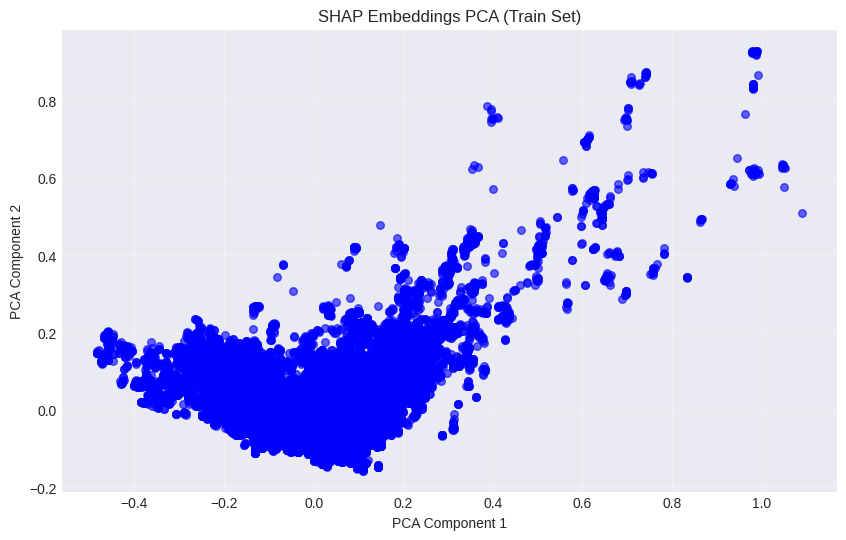

In [59]:
# Визуализация первых двух компонент PCA
x = shap_train_pca[:, 0]
y = shap_train_pca[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, c='blue', alpha=0.6, s=30)
plt.title('SHAP Embeddings PCA (Train Set)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.show()

Размеры кластеров (KMeans):
Кластер 0: 64201 объектов
Кластер 1: 62939 объектов
Кластер 2: 93087 объектов
Кластер 3: 1298 объектов


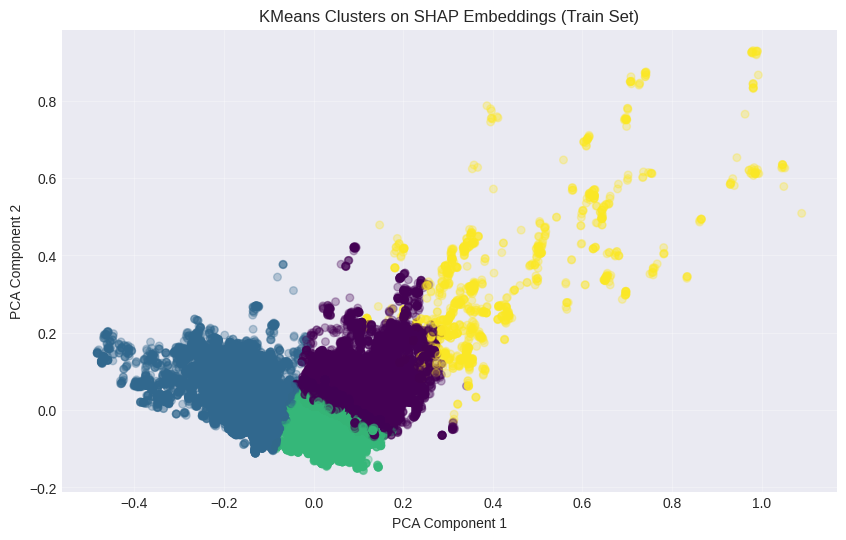

In [60]:
# KMean на сжатых SHAP эмбеддингах
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters_train_km = kmeans.fit_predict(shap_train_pca)
clusters_test_km  = kmeans.predict(shap_test_pca)

unique, counts = np.unique(clusters_train_km, return_counts=True)
print("Размеры кластеров (KMeans):")
for c, n in zip(unique, counts):
    print(f"Кластер {c}: {n} объектов")

x = shap_train_pca[:, 0]
y = shap_train_pca[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(shap_train_pca[:, 0], shap_train_pca[:, 1],
            c=clusters_train_km, cmap='viridis', alpha=0.3, s=30)
plt.title('KMeans Clusters on SHAP Embeddings (Train Set)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
# Анализ кластеров
import pandas as pd

data = X_train.copy()
data["cluster_km"] = clusters_train_km
data["target"] = y_train.values

cluster_summary = (
    data
    .groupby("cluster_km")
    .agg(["mean", "count"])
).round(2)

cluster_summary

Window_Volatility        Log_Return_min_ratio_192to384         \
                        mean  count                          mean  count   
cluster_km                                                                 
0                    4051.74  64201                          0.72  64201   
1                    5318.43  62939                          0.80  62939   
2                    6275.84  93087                          0.87  93087   
3                    1142.89   1298                          0.57   1298   

           Avg_Volume_per_Trade_min_ratio_192to384         \
                                              mean  count   
cluster_km                                                  
0                                            78.92  64201   
1                                            19.60  62939   
2                                           103.59  93087   
3                                             1.04   1298   

           Taker_Buy_Ratio_max_ratio_192to384         \
                                         mean  count   
cluster_km                                             
0                                        0.98  64201   
1                                        0.97  62939   
2                                        0.97  93087   
3                                        0.97   1298   

           Log_Return_Abs_min_ratio_192to384         ...  \
                                        mean  count  ...   
cluster_km                                           ...   
0                                       2.51  64201  ...   
1                                       3.11  62939  ...   
2                                       3.45  93087  ...   
3                                       1.74   1298  ...   

           Abs_Range_max_ratio_96to192         \
                                  mean  count   
cluster_km                                      
0                                 0.74  64201   
1                                 0.79  62939   
2                                 0.89  93087   
3                                 0.73   1298   

           Taker_Buy_Ratio_max_ratio_96to192        month_sin         \
                                        mean  count      mean  count   
cluster_km                                                             
0                                       0.97  64201      0.02  64201   
1                                       0.97  62939      0.04  62939   
2                                       0.97  93087      0.06  93087   
3                                       0.98   1298     -0.49   1298   

           Taker_Buy_Ratio_std_rel_to_lag_384        target         
                                         mean  count   mean  count  
cluster_km                                                          
0                                        1.02  64201   1.32  64201  
1                                        0.97  62939   0.89  62939  
2                                        1.03  93087   0.97  93087  
3                                        1.03   1298   3.67   1298  

[4 rows x 62 columns]

In [62]:
# добавляем кластер как фичу
X_train_cluster = X_train.copy()
X_test_cluster  = X_test.copy()

X_train_cluster["cluster_km"] = clusters_train_km
X_test_cluster["cluster_km"]  = clusters_test_km

# модель с кластером
gb_cluster = GradientBoostingRegressor(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
gb_cluster.fit(X_train_cluster, y_train)

y_pred_cluster = gb_cluster.predict(X_test_cluster)
mae_cluster = mean_absolute_error(y_test, y_pred_cluster)

print("MAE базовой модели (gb_new):", mae_before)
print("MAE модели с кластером:", mae_cluster)
print("Изменение MAE:", mae_cluster - mae_before)


MAE базовой модели (gb_new): 0.2842410404444347
MAE модели с кластером: 0.2873064002139854
Изменение MAE: 0.0030653597695506907


### Валидация

In [63]:
X = pd.concat([X_train, X_test])
y = pd.concat([y_train, y_test])

In [64]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=3, shuffle=True, random_state=42)

N_ESTIMATORS_KF = 50

maes_emb = []
maes_concat = []
maes_baseline = []

fold = 0
for tr_idx, val_idx in kf.split(X):
    fold += 1
    X_train, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # обучаем базовую модель на исходных признаках
    base = GradientBoostingRegressor(
        n_estimators=N_ESTIMATORS_KF,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )

    base.fit(X_train, y_train)

    y_val_pred_base = base.predict(X_val)
    mae_base = mean_absolute_error(y_val, y_val_pred_base)
    maes_baseline.append(mae_base)

    # получаем SHAP-эмбеддинги
    shap_train = get_shap_embedings(base, X_train)
    shap_val = get_shap_embedings(base, X_val)

    # обучаем модель на SHAP-эмбеддингах
    model_emb = GradientBoostingRegressor(
        n_estimators=N_ESTIMATORS_KF,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )

    model_emb.fit(shap_train, y_train)

    y_val_pred_emb = model_emb.predict(shap_val)
    maes_emb.append(mean_absolute_error(y_val, y_val_pred_emb))

    # обучаем модель на конкатенации
    X_train_concat = np.hstack([X_train.values, shap_train])
    X_val_concat = np.hstack([X_val.values, shap_val])

    model_concat = GradientBoostingRegressor(
        n_estimators=N_ESTIMATORS_KF,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )

    model_concat.fit(X_train_concat, y_train)

    y_val_pred_concat = model_concat.predict(X_val_concat)
    maes_concat.append(mean_absolute_error(y_val, y_val_pred_concat))

    print(f"[Fold {fold}] MAE baseline: {mae_base:.4f}, emb: {maes_emb[-1]:.4f}, concat: {maes_concat[-1]:.4f}")

[Fold 1] MAE baseline: 0.2448, emb: 0.2355, concat: 0.2354
[Fold 2] MAE baseline: 0.2440, emb: 0.2329, concat: 0.2330
[Fold 3] MAE baseline: 0.2443, emb: 0.2342, concat: 0.2335


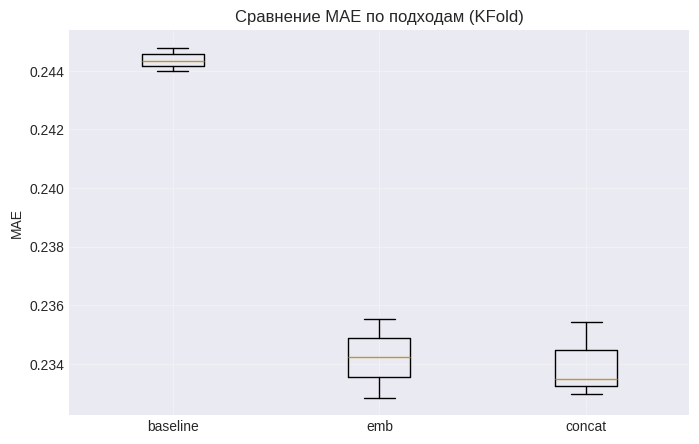

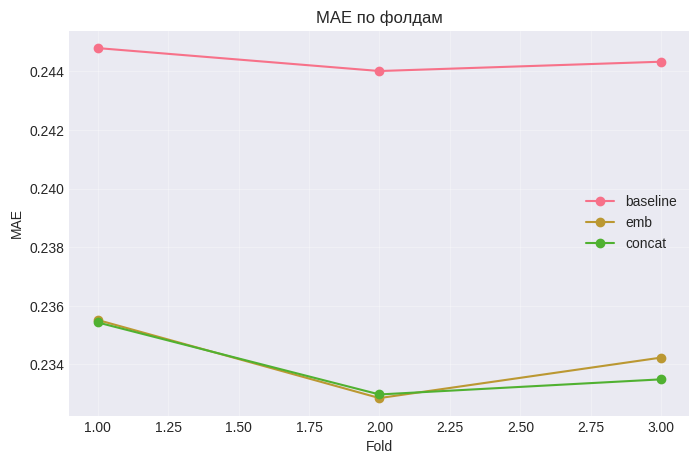

In [65]:
# Визуализация MAE по фолдам
plt.figure(figsize=(8,5))
plt.boxplot([maes_baseline, maes_emb, maes_concat], labels=['baseline', 'emb', 'concat'])
plt.ylabel('MAE')
plt.title('Сравнение MAE по подходам (KFold)')
plt.grid(alpha=0.3)
plt.show()

# Разница по фолдам (сплаттер)
plt.figure(figsize=(8,5))
x = np.arange(1, len(maes_emb)+1)
plt.plot(x, maes_baseline, marker='o', label='baseline')
plt.plot(x, maes_emb, marker='o', label='emb')
plt.plot(x, maes_concat, marker='o', label='concat')
plt.xlabel('Fold')
plt.ylabel('MAE')
plt.legend()
plt.title('MAE по фолдам')
plt.grid(alpha=0.3)
plt.show()

### Построение графа взаимосвязей признаков и Shapley Flow

In [66]:
import xgboost as xgb
from shapflow.flow import CausalLinks, build_feature_graph, GraphExplainer, create_xgboost_f

# Для удобства переопределим переменные
model = model_selected

X_train = X_train_selected.copy()
X_test  = X_test_selected.copy()

y_train = y_train_selected.copy()
y_test  = y_test_selected.copy()

best_features = list(X_train.columns)

In [67]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'mae',
    'seed': 42,
    'max_depth': 6,
    'learning_rate': 0.1
}

xgb_model = xgb.train(params, dtrain, num_boost_round=100)

In [70]:
causal_links = CausalLinks()

target_name = 'Target'

causal_links.add_causes_effects(
    best_features,
    target_name,
    create_xgboost_f(best_features, xgb_model)
)

graph = build_feature_graph(
    X=X_test.iloc[:500],
    causal_links=causal_links,
    categorical_feature_names=[],
    target_name=target_name
)
plt.figure(figsize=(12, 9))
graph.draw()

0it [00:00, ?it/s]


<Figure size 1200x900 with 0 Axes>

bruteforce sampling: 100%|██████████| 150/150 [01:11<00:00,  2.11it/s]

Shapley Flow для объекта 42:


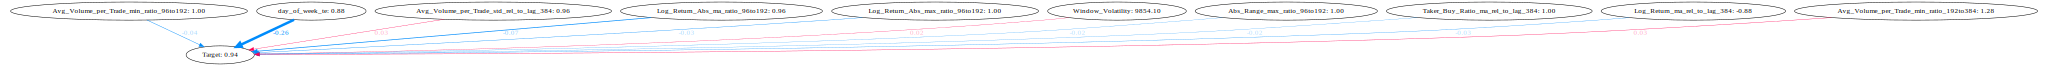

Shapley Flow для объекта 100:


Shapley Flow для объекта 223:


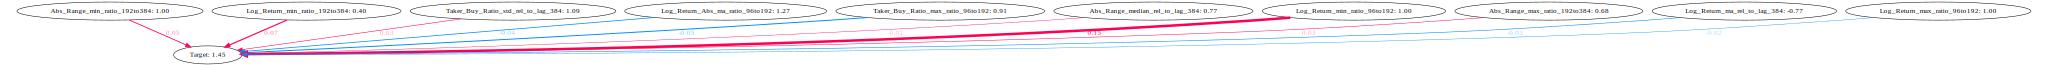

In [71]:
# Локальная интерпретация через Shapley Flow
background = X_test.iloc[[100]]
foreground = X_test.iloc[ids]

explainer_flow = GraphExplainer(graph, background, nruns=150)
flow_explanations = explainer_flow.shap_values(foreground)

for idx, obj_idx in enumerate(ids):
    print(f"Shapley Flow для объекта {obj_idx}:")
    flow_explanations.draw(idx, max_display=10, show_fg_val=True)

In [72]:
explainer_shap = shap.TreeExplainer(xgb_model)

sample_indices = np.random.choice(len(X_train), 2000, replace=False)
X_train_sample = X_train.iloc[sample_indices]

shap_inter = explainer_shap.shap_interaction_values(X_train_sample)

flow_emb = np.array(shap_inter).reshape(len(X_train_sample), -1)

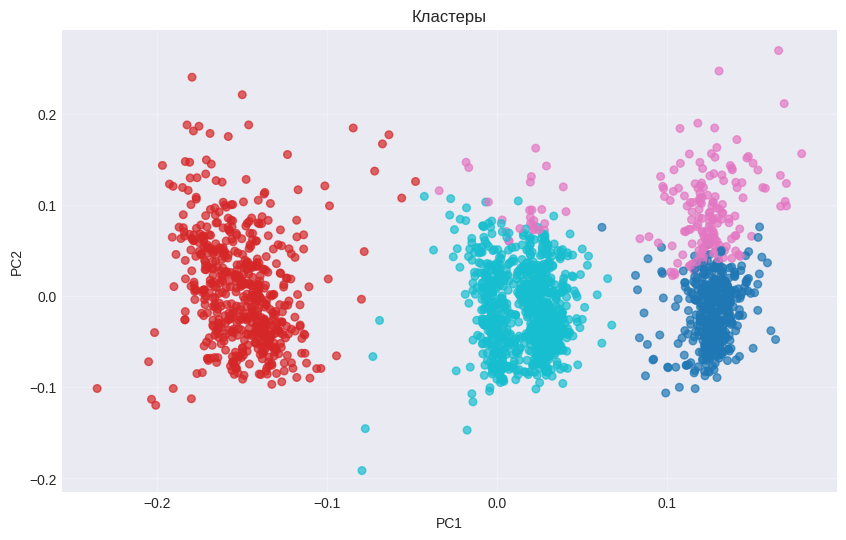

In [73]:
# Кластеризация
pca = PCA(n_components=5, random_state=42)
flow_pca = pca.fit_transform(flow_emb)

kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
clusters_flow = kmeans.fit_predict(flow_pca)

plt.figure(figsize=(10,6))
plt.scatter(flow_pca[:,0], flow_pca[:,1], c=clusters_flow, cmap='tab10', alpha=0.7, s=30)
plt.title("Кластеры")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

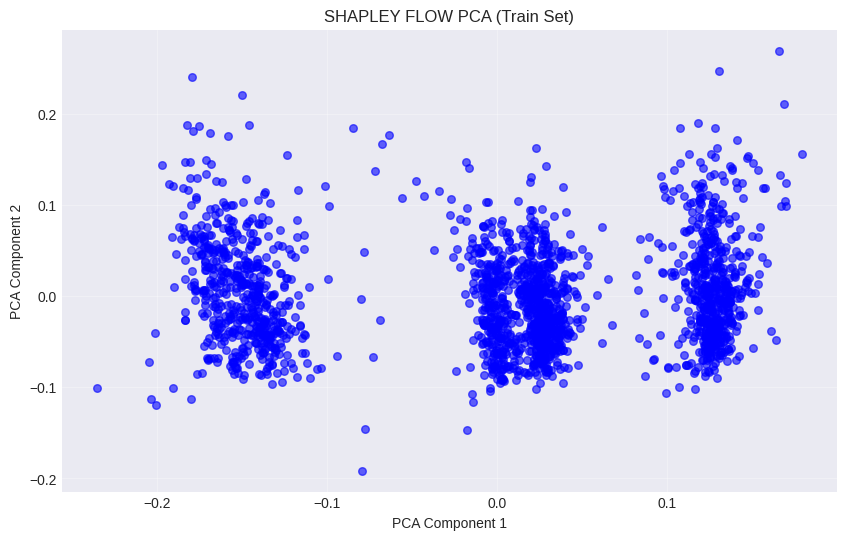

In [74]:
# Визуализация первых двух компонент PCA
x = flow_pca[:, 0]
y = flow_pca[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, c='blue', alpha=0.6, s=30)
plt.title('SHAPLEY FLOW PCA (Train Set)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.show()

In [75]:
# Аномалии
iso = IsolationForest(contamination='auto', random_state=42)
anomalies = iso.fit_predict(flow_emb)

print(f"Аномалий в Shapley Flow: {(anomalies == -1).sum()} ({(anomalies == -1).mean():.1%})")

Аномалий в Shapley Flow: 2 (0.1%)


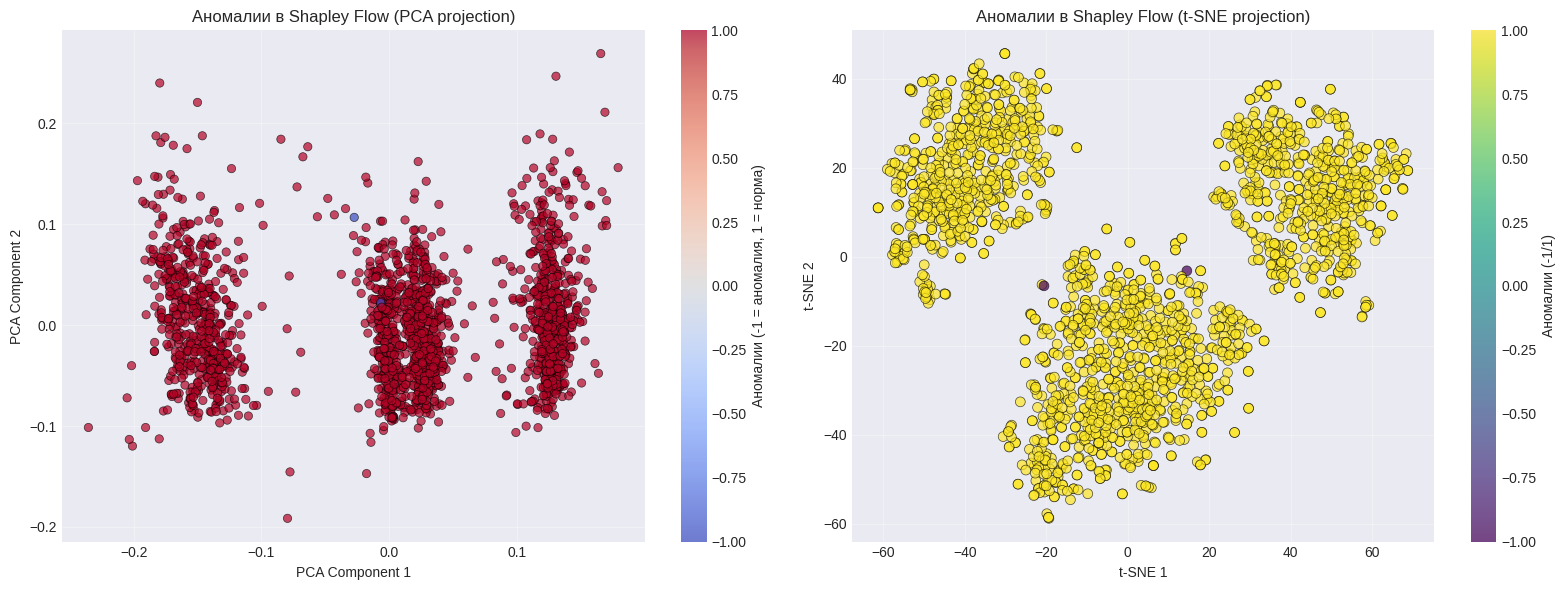

Статистика по группам:
Всего точек: 2000
Нормальных точек (1): 1998 (99.90%)
Аномальных точек (-1): 2 (0.10%)


In [76]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Уменьшаем размерность до 2D
pca = PCA(n_components=2)
flow_emb_2d = pca.fit_transform(flow_emb)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
scatter1 = axes[0].scatter(flow_emb_2d[:, 0], flow_emb_2d[:, 1],
                     c=anomalies, cmap='coolwarm', alpha=0.7,
                     edgecolors='k', linewidth=0.5)

axes[0].set_title('Аномалии в Shapley Flow (PCA projection)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].grid(True, alpha=0.3)

# colorbar для PCA
cbar1 = fig.colorbar(scatter1, ax=axes[0], orientation='vertical')
cbar1.set_label('Аномалии (-1 = аномалия, 1 = норма)')

# T-SNE для нелинейного снижения размерности
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
flow_emb_tsne = tsne.fit_transform(flow_emb)

# T-SNE
scatter2 = axes[1].scatter(flow_emb_tsne[:, 0], flow_emb_tsne[:, 1],
                     c=anomalies, cmap='viridis', alpha=0.7,
                     s=50, edgecolors='k', linewidth=0.5)

axes[1].set_title('Аномалии в Shapley Flow (t-SNE projection)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)

# colorbar для T-SNE
cbar2 = fig.colorbar(scatter2, ax=axes[1], orientation='vertical')
cbar2.set_label('Аномалии (-1/1)')

plt.tight_layout()
plt.show()


print("Статистика по группам:")
print(f"Всего точек: {len(anomalies)}")
print(f"Нормальных точек (1): {(anomalies == 1).sum()} ({(anomalies == 1).mean():.2%})")
print(f"Аномальных точек (-1): {(anomalies == -1).sum()} ({(anomalies == -1).mean():.2%})")

Итого:
- Интерпретировали модель
- Показали аномалии и кластеры
- Получилось улучшить качество модели